# Loan Default Prediction — Complete 6-Week Deep Learning Pipeline
**Student:** Isaac Kwarteng-Addo | **ID:** 7825035955 | **Submitted:** June 2026

## Project Objective
Predict loan default using LendingClub data (2007–2018).  
Demonstrate that a properly engineered **Deep Feedforward Neural Network (FNN) outperforms** Logistic Regression and Random Forest.

## Week Structure
| Week | Focus | Steps |
|------|-------|-------|
| 1 | Problem Framing & Data Acquisition | 0–1 |
| 2 | Data Preprocessing | 2–3 |
| 3 | EDA & Feature Engineering | 4–5 |
| 4 | Baseline Modelling (LR + RF) | 6–10 |
| 5 | Deep Neural Network | 11–13 |
| 6 | Final Evaluation, SHAP & Improvements | 14–18 |

## DNN Architecture
```
Input (N features, standardised)
  ↓ FeatureAttention gate             ← NEW in v2
  ↓ InputProjection: Linear→BN→GELU
  ↓ ResidualBlock(512→256): Linear→BN→GELU→Dropout→Linear→BN + skip
  ↓ ResidualBlock(256→128)
  ↓ ResidualBlock(128→64)
  ↓ ResidualBlock(64→32)
  ↓ OutputHead: Linear(32→1) → sigmoid
Loss: Focal Loss (α=0.25, γ=2) | Optim: AdamW | Scheduler: CosineAnnealingWarmRestarts
Imbalance: WeightedRandomSampler | v2 adds: Mixup + Label Smoothing
```

---
# WEEK 1 — Problem Framing & Data Acquisition
## Step 0 — Setup & Imports

In [3]:
# ================================================================
# STEP 0 -- INSTALL & IMPORT ALL DEPENDENCIES
# ================================================================
import subprocess, sys
def pip(pkg): subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg])
pip('torch'); pip('imbalanced-learn'); pip('optuna'); pip('shap')

import os, re, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.sparse as sp
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, roc_auc_score, average_precision_score,
    brier_score_loss, confusion_matrix, classification_report,
    log_loss, matthews_corrcoef, roc_curve, precision_recall_curve)
from sklearn.calibration import calibration_curve
import statsmodels.api as sm

try:
    from imblearn.over_sampling import SMOTE
    IMBLEARN_AVAILABLE = True; print('✓ imbalanced-learn')
except ImportError:
    IMBLEARN_AVAILABLE = False; print('✗ imbalanced-learn')

try:
    import torch, torch.nn as nn, torch.nn.functional as F
    from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
    from torch.optim import AdamW
    from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
    TORCH_AVAILABLE = True
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'✓ PyTorch {torch.__version__} | device: {DEVICE}')
except ImportError:
    TORCH_AVAILABLE = False; print('✗ PyTorch')

try:
    import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True; print('✓ Optuna')
except ImportError:
    OPTUNA_AVAILABLE = False; print('✗ Optuna')

try:
    import shap; SHAP_AVAILABLE = True; print('✓ SHAP')
except ImportError:
    SHAP_AVAILABLE = False; print('✗ SHAP')

warnings.filterwarnings('ignore')
SEED = 42; np.random.seed(SEED)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style('whitegrid')

# ── Helper functions ──────────────────────────────────────────
def clean_percent(val):
    if pd.isna(val): return np.nan
    if isinstance(val, (int, float)): return float(val)
    return float(str(val).replace('%','').strip())

def clean_employment_length(val):
    if pd.isna(val): return np.nan
    val = str(val).lower().strip()
    if '10+' in val: return 10.0
    if '< 1' in val: return 0.5
    m = re.search(r'(\d+)', val)
    return float(m.group(1)) if m else np.nan

def to_dense_float32(X):
    return X.toarray().astype(np.float32) if sp.issparse(X) else np.asarray(X, dtype=np.float32)

def evaluate_model(name, model, X_tr, y_tr, X_val, y_val, X_te, y_te):
    rows = []
    for split_name, Xs, ys in [('Train',X_tr,y_tr),('Val',X_val,y_val),('Test',X_te,y_te)]:
        prob = model.predict_proba(Xs)[:,1]
        pred = (prob >= 0.5).astype(int)
        tn,fp,fn,tp = confusion_matrix(ys,pred).ravel()
        rows.append({
            'Model':name,'Split':split_name,
            'Accuracy':      accuracy_score(ys,pred),
            'Precision':     precision_score(ys,pred,zero_division=0),
            'Recall':        recall_score(ys,pred,zero_division=0),
            'Specificity':   tn/(tn+fp+1e-9),
            'F1':            f1_score(ys,pred,zero_division=0),
            'Balanced_Acc':  balanced_accuracy_score(ys,pred),
            'ROC_AUC':       roc_auc_score(ys,prob),
            'PR_AUC':        average_precision_score(ys,prob),
            'MCC':           matthews_corrcoef(ys,pred),
            'Log_Loss':      log_loss(ys,prob),
            'Brier':         brier_score_loss(ys,prob),
            'TN':tn,'FP':fp,'FN':fn,'TP':tp})
    return pd.DataFrame(rows)

print('\n✓ Setup complete.')

✓ imbalanced-learn
✓ PyTorch 2.12.0+cpu | device: cpu
✓ Optuna
✓ SHAP

✓ Setup complete.


## Step 1 — Load Data
> **Week 1 deliverable:** Dataset loaded, shape confirmed, loan_status distribution documented.

In [5]:
# ================================================================
# STEP 1 -- LOAD DATASET
# ================================================================
# Option A: Full path
FILE_PATH = r'C:/Users/ikadd/Downloads/loan.csv'  # ← update this

# Option B: Same folder as notebook → FILE_PATH = 'loan.csv'
# Option C: Compressed  → FILE_PATH = 'accepted_2007_to_2018Q4.csv.gz'

compression = 'gzip' if FILE_PATH.endswith('.gz') else None
raw_df = pd.read_csv(FILE_PATH, compression=compression, low_memory=False)
df     = raw_df.copy()

print(f'Raw dataset: {raw_df.shape[0]:,} rows × {raw_df.shape[1]} columns')

vc = raw_df['loan_status'].value_counts(dropna=False)
status_table = pd.DataFrame({'Count': vc, 'Pct (%)': (vc/len(raw_df)*100).round(2)})
print('\nTable 1: Loan Status Distribution (raw dataset)')
display(status_table)
print('\nFirst 3 rows:')
display(raw_df.head(3))

Raw dataset: 1,048,575 rows × 151 columns

Table 1: Loan Status Distribution (raw dataset)


,Count,Pct (%)
loan_status,,
Fully Paid,482595,46.02
Current,419550,40.01
Charged Off,129187,12.32
Late (31-120 days),10879,1.04
In Grace Period,4227,0.40
Late (16-30 days),2104,0.20
Default,21,0.00
NaN,12,0.00



First 3 rows:


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


---
# WEEK 2 — Data Preprocessing
## Step 2 — Column Renaming & Target / Leakage

In [7]:
# ================================================================
# STEP 2 -- RENAME COLUMNS + TARGET CREATION + LEAKAGE REMOVAL
# ================================================================
RENAME_MAP = {
    'loan_status':'Loan_Status','loan_amnt':'Loan_Amount',
    'funded_amnt':'Funded_Amount','term':'Loan_Term',
    'int_rate':'Interest_Rate','installment':'Monthly_Installment',
    'grade':'Credit_Grade','sub_grade':'Credit_Sub_Grade',
    'purpose':'Loan_Purpose','initial_list_status':'Initial_Listing_Status',
    'annual_inc':'Annual_Income','dti':'Debt_To_Income_Ratio',
    'emp_length':'Employment_Length','home_ownership':'Home_Ownership',
    'verification_status':'Income_Verification_Status',
    'application_type':'Application_Type','fico_range_low':'FICO_Score',
    'delinq_2yrs':'Delinquencies_Last_2_Years',
    'inq_last_6mths':'Credit_Inquiries_Last_6_Months',
    'open_acc':'Open_Credit_Lines','pub_rec':'Public_Derogatory_Records',
    'revol_bal':'Revolving_Balance','revol_util':'Revolving_Utilisation_Rate',
    'total_acc':'Total_Credit_Lines','earliest_cr_line':'Earliest_Credit_Line_Date',
    'pub_rec_bankruptcies':'Public_Record_Bankruptcies',
    'acc_open_past_24mths':'Accounts_Opened_Last_24_Months',
    'avg_cur_bal':'Average_Current_Balance','bc_open_to_buy':'Bankcard_Open_To_Buy',
    'bc_util':'Bankcard_Utilisation_Rate',
    'mo_sin_old_il_acct':'Months_Since_Oldest_Installment_Account',
    'mo_sin_old_rev_tl_op':'Months_Since_Oldest_Revolving_Account',
    'mo_sin_rcnt_rev_tl_op':'Months_Since_Recent_Revolving_Account',
    'mo_sin_rcnt_tl':'Months_Since_Recent_Account',
    'mort_acc':'Mortgage_Accounts',
    'num_accts_ever_120_pd':'Accounts_120_Days_Past_Due',
    'num_actv_bc_tl':'Active_Bankcard_Accounts','issue_d':'Issue_Date',
}
actual = {k:v for k,v in RENAME_MAP.items() if k in df.columns}
df = df.rename(columns=actual)
print(f'Renamed {len(actual)} columns.')

# Target: 1=Default/Charged Off, 0=Fully Paid
FINAL_STATUSES = ['Fully Paid','Charged Off','Default']
df = df[df['Loan_Status'].isin(FINAL_STATUSES)].copy()
df['Default'] = df['Loan_Status'].isin(['Charged Off','Default']).astype(int)

# Remove 18 data-leakage columns (post-loan outcome info)
LEAKAGE = ['out_prncp','out_prncp_inv','total_pymnt','total_pymnt_inv',
           'total_rec_prncp','total_rec_int','total_rec_late_fee',
           'recoveries','collection_recovery_fee','last_pymnt_d',
           'last_pymnt_amnt','next_pymnt_d','last_credit_pull_d',
           'last_fico_range_high','last_fico_range_low',
           'debt_settlement_flag','chargeoff_within_12_mths',
           'acc_now_delinq','delinq_amnt','Loan_Status']
df = df.drop(columns=[c for c in LEAKAGE if c in df.columns])
print(f'After leakage removal: {df.shape}')

Renamed 38 columns.
After leakage removal: (611803, 132)


## Step 3 — Missing Value Audit & Cleaning

Table 2: Missing Value Severity Breakdown


,Count,count
0,None (0%),60
1,Critical (>70%),41
2,High (30–70%),16
3,Low (<5%),12
4,Moderate (5–30%),3


Dropped 57 columns with ≥30% missing.
Filled 0 NaN cells with 0 (count columns).
Dropped 218 rows with NaN in critical columns.

Table 3: Data Pipeline Summary


,Item,Result
0,Raw rows,"1,048,575"
1,Raw columns,151
2,Columns dropped (≥30% missing),57
3,Rows removed (non-final status),"436,772"
4,NaN cells filled with 0,0
5,Rows dropped (critical NaN),218
6,Final rows,"611,585"
7,Final columns,75
8,Missing values remaining,218264
9,Default rate,21.1%


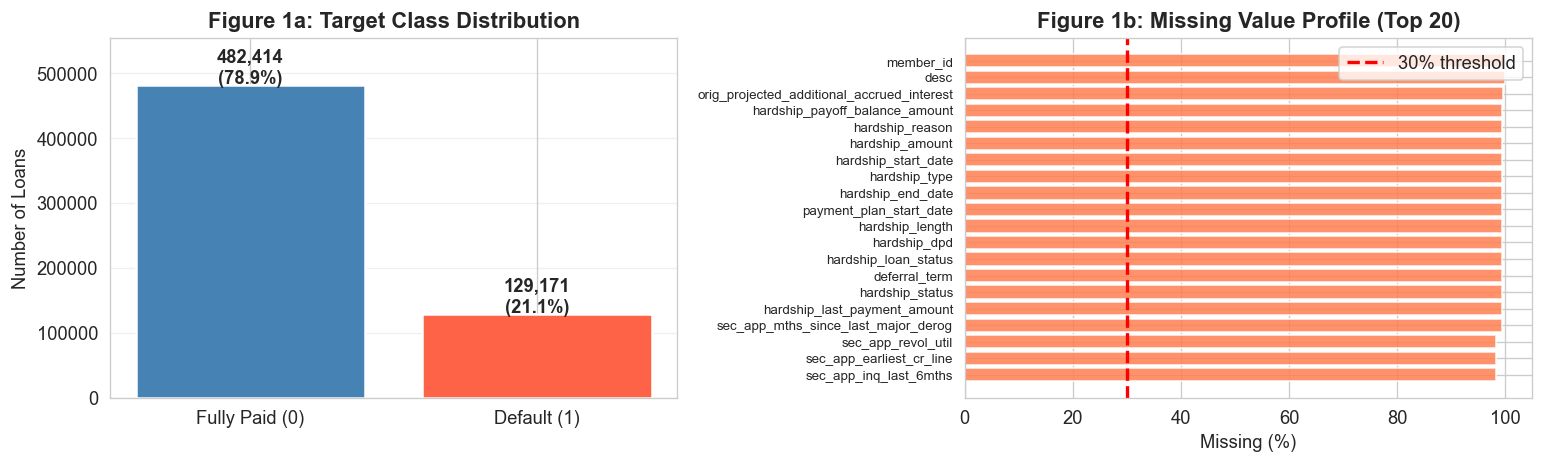

Final dataset: 611,585 rows × 75 columns


In [9]:
# ================================================================
# STEP 3 -- MISSING VALUE AUDIT + CLEANING
# ================================================================
missing_pct = (df.isna().mean()*100).sort_values(ascending=False)

def severity(p):
    if p==0:    return 'None (0%)'
    elif p<5:   return 'Low (<5%)'
    elif p<30:  return 'Moderate (5–30%)'
    elif p<70:  return 'High (30–70%)'
    else:       return 'Critical (>70%)'

sev_df = pd.DataFrame({'Feature':missing_pct.index,'Missing_Pct':missing_pct.values})
sev_df['Severity'] = sev_df['Missing_Pct'].apply(severity)
print('Table 2: Missing Value Severity Breakdown')
display(sev_df['Severity'].value_counts().reset_index().rename(columns={'index':'Severity','Severity':'Count'}))

# Drop ≥30% missing
drop_cols = missing_pct[missing_pct>=30].index.tolist()
df = df.drop(columns=drop_cols)
print(f'Dropped {len(drop_cols)} columns with ≥30% missing.')

# Fill NaN=0 for count columns
zero_fill = ['Mortgage_Accounts','Public_Record_Bankruptcies',
             'Accounts_120_Days_Past_Due','Active_Bankcard_Accounts',
             'Accounts_Opened_Last_24_Months','Delinquencies_Last_2_Years',
             'Credit_Inquiries_Last_6_Months','Public_Derogatory_Records']
filled = 0
for col in zero_fill:
    if col in df.columns:
        n = df[col].isna().sum(); df[col].fillna(0, inplace=True); filled+=n
print(f'Filled {filled:,} NaN cells with 0 (count columns).')

# Drop rows with NaN in critical fields
critical = [c for c in ['Annual_Income','Debt_To_Income_Ratio','FICO_Score'] if c in df.columns]
rows_before = len(df)
df = df.dropna(subset=critical)
print(f'Dropped {rows_before-len(df):,} rows with NaN in critical columns.')

# Table 3: Pipeline summary
pipeline_summary = pd.DataFrame({
    'Item':['Raw rows','Raw columns','Columns dropped (≥30% missing)',
            'Rows removed (non-final status)','NaN cells filled with 0',
            'Rows dropped (critical NaN)','Final rows','Final columns',
            'Missing values remaining','Default rate'],
    'Result':[f'{raw_df.shape[0]:,}',str(raw_df.shape[1]),str(len(drop_cols)),
              f'{raw_df.shape[0]-len(df)-(rows_before-len(df)):,}',
              f'{filled:,}',f'{rows_before-len(df):,}',
              f'{len(df):,}',str(df.shape[1]),
              str(df.isna().sum().sum()),f'{df["Default"].mean():.1%}']
})
print('\nTable 3: Data Pipeline Summary')
display(pipeline_summary)

# Figure 1: Class distribution + missing value bar
fig, axes = plt.subplots(1,2,figsize=(13,4))
counts = df['Default'].value_counts().sort_index()
axes[0].bar(['Fully Paid (0)','Default (1)'],counts.values,
            color=['steelblue','tomato'],edgecolor='white',linewidth=1.5)
for i,v in enumerate(counts.values):
    axes[0].text(i,v+2000,f'{v:,}\n({v/len(df)*100:.1f}%)',ha='center',fontweight='bold')
axes[0].set_title('Figure 1a: Target Class Distribution',fontweight='bold')
axes[0].set_ylabel('Number of Loans'); axes[0].set_ylim(0,counts.max()*1.15)
axes[0].grid(axis='y',alpha=0.3)

top20 = missing_pct[missing_pct>0].head(20)
axes[1].barh(range(len(top20)),top20.values[::-1],color='coral',alpha=0.85)
axes[1].set_yticks(range(len(top20)))
axes[1].set_yticklabels(top20.index[::-1],fontsize=8)
axes[1].axvline(x=30,color='red',linestyle='--',lw=2,label='30% threshold')
axes[1].set_title('Figure 1b: Missing Value Profile (Top 20)',fontweight='bold')
axes[1].set_xlabel('Missing (%)'); axes[1].legend()
plt.tight_layout()
plt.savefig('fig1_class_missing.png',dpi=150,bbox_inches='tight')
plt.show()
print(f'Final dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')

---
# WEEK 3 — EDA & Feature Engineering
## Step 4 — Exploratory Data Analysis

Table 4: Descriptive Statistics for Key Numeric Features


,count,mean,std,min,25%,50%,75%,max,skewness
Loan_Amount,611585.0,14558.12,8807.36,1000.00,8000.00,12000.00,20000.00,40000.00,0.77
Interest_Rate,611585.0,12.72,4.79,5.31,9.17,12.29,15.59,30.99,0.85
Annual_Income,611585.0,76901.90,74321.86,16.00,45723.00,65000.00,91800.00,10999200.00,49.64
Debt_To_Income_Ratio,611585.0,18.95,11.85,-1.00,12.17,18.18,24.96,999.00,27.84
FICO_Score,611585.0,695.53,31.93,660.00,670.00,690.00,710.00,845.00,1.32
Revolving_Utilisation_Rate,611259.0,50.63,24.49,0.00,32.20,50.50,69.30,193.00,0.00
Revolving_Balance,611585.0,16550.03,23566.64,0.00,5834.00,11017.00,19832.00,2904836.00,12.54
Monthly_Installment,611585.0,439.34,263.36,14.01,248.30,374.14,584.32,1719.83,1.01


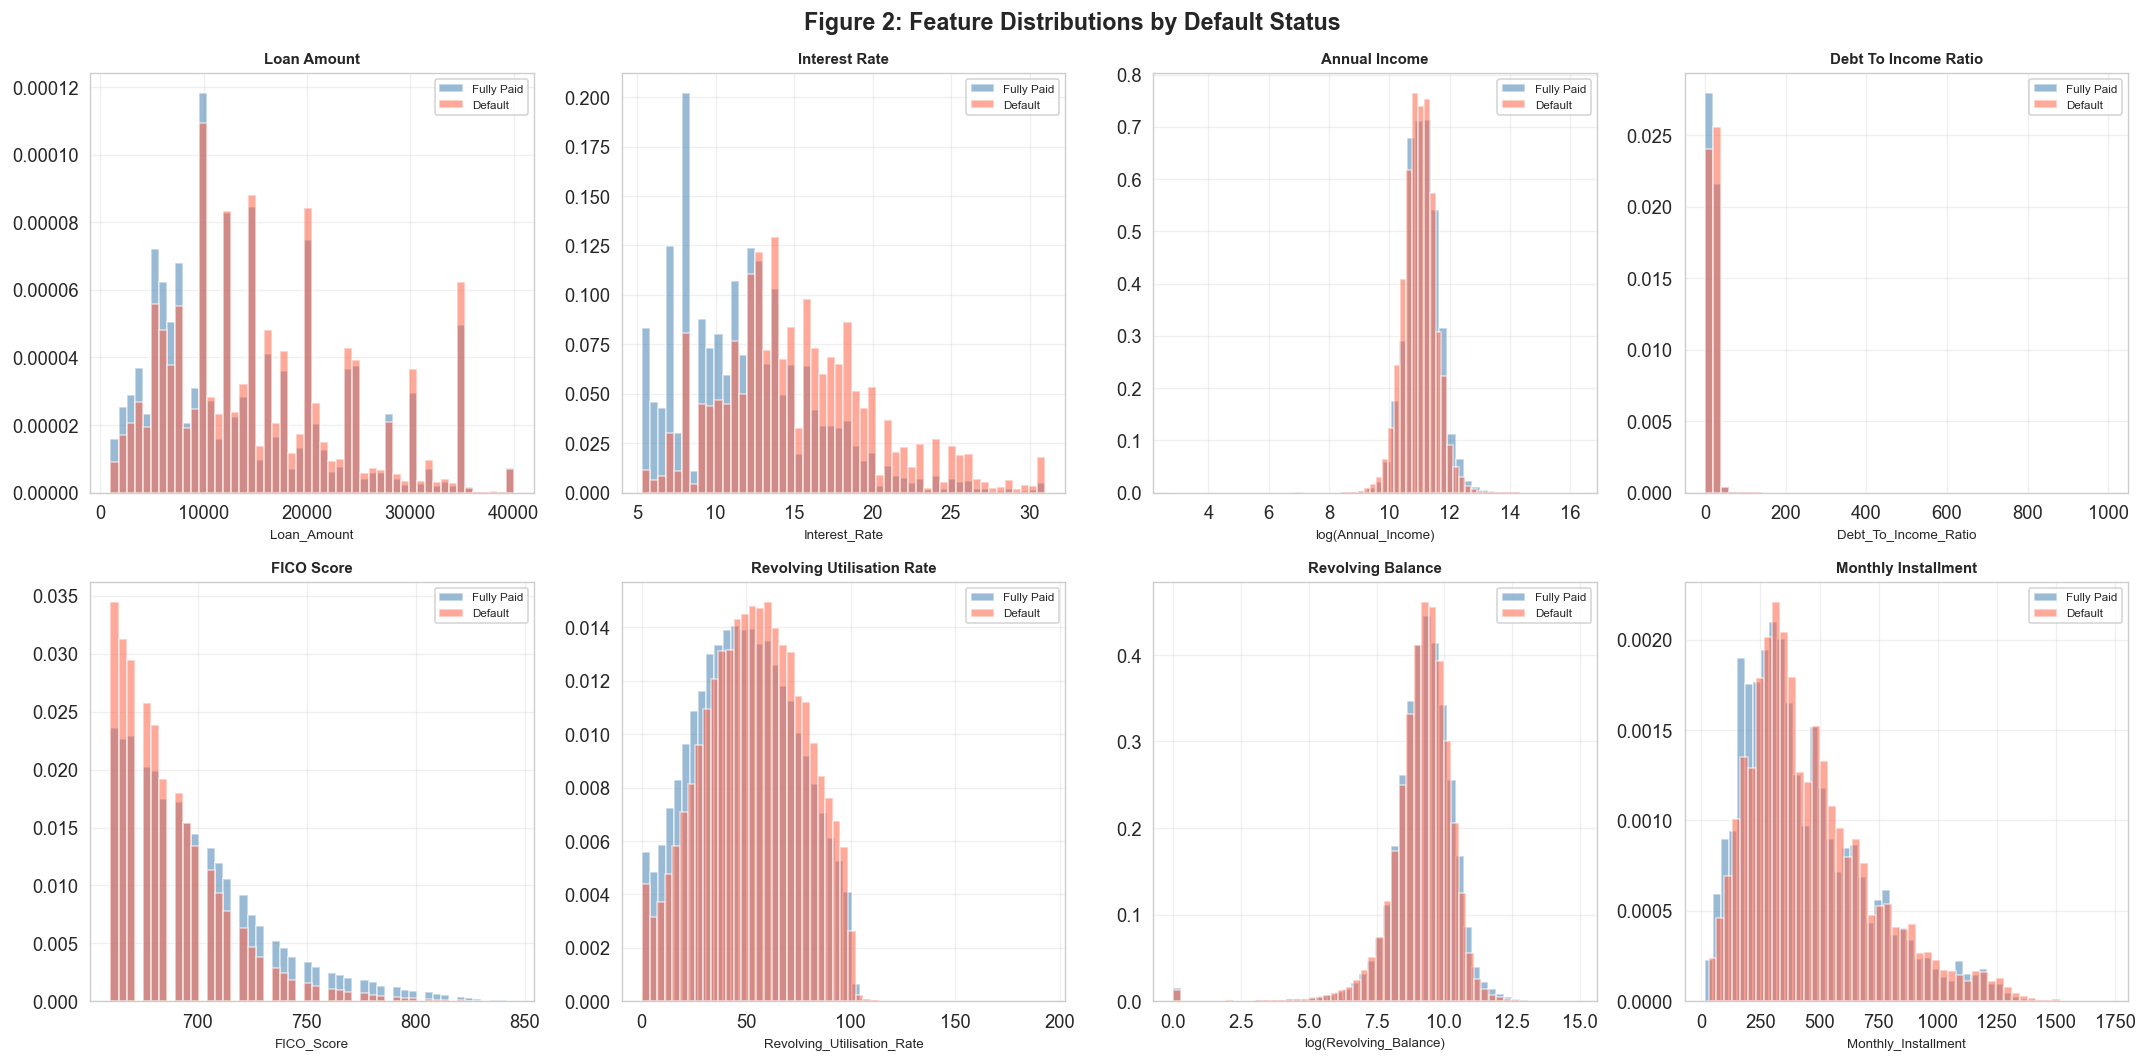

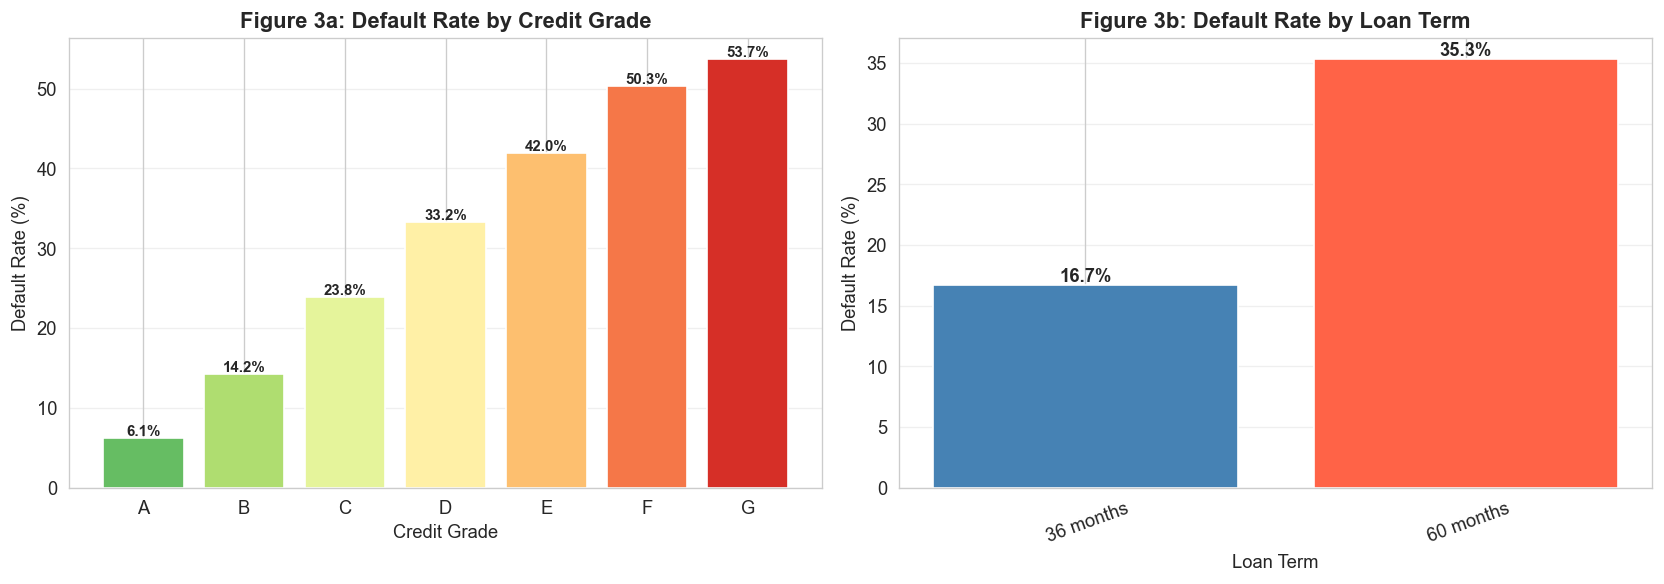

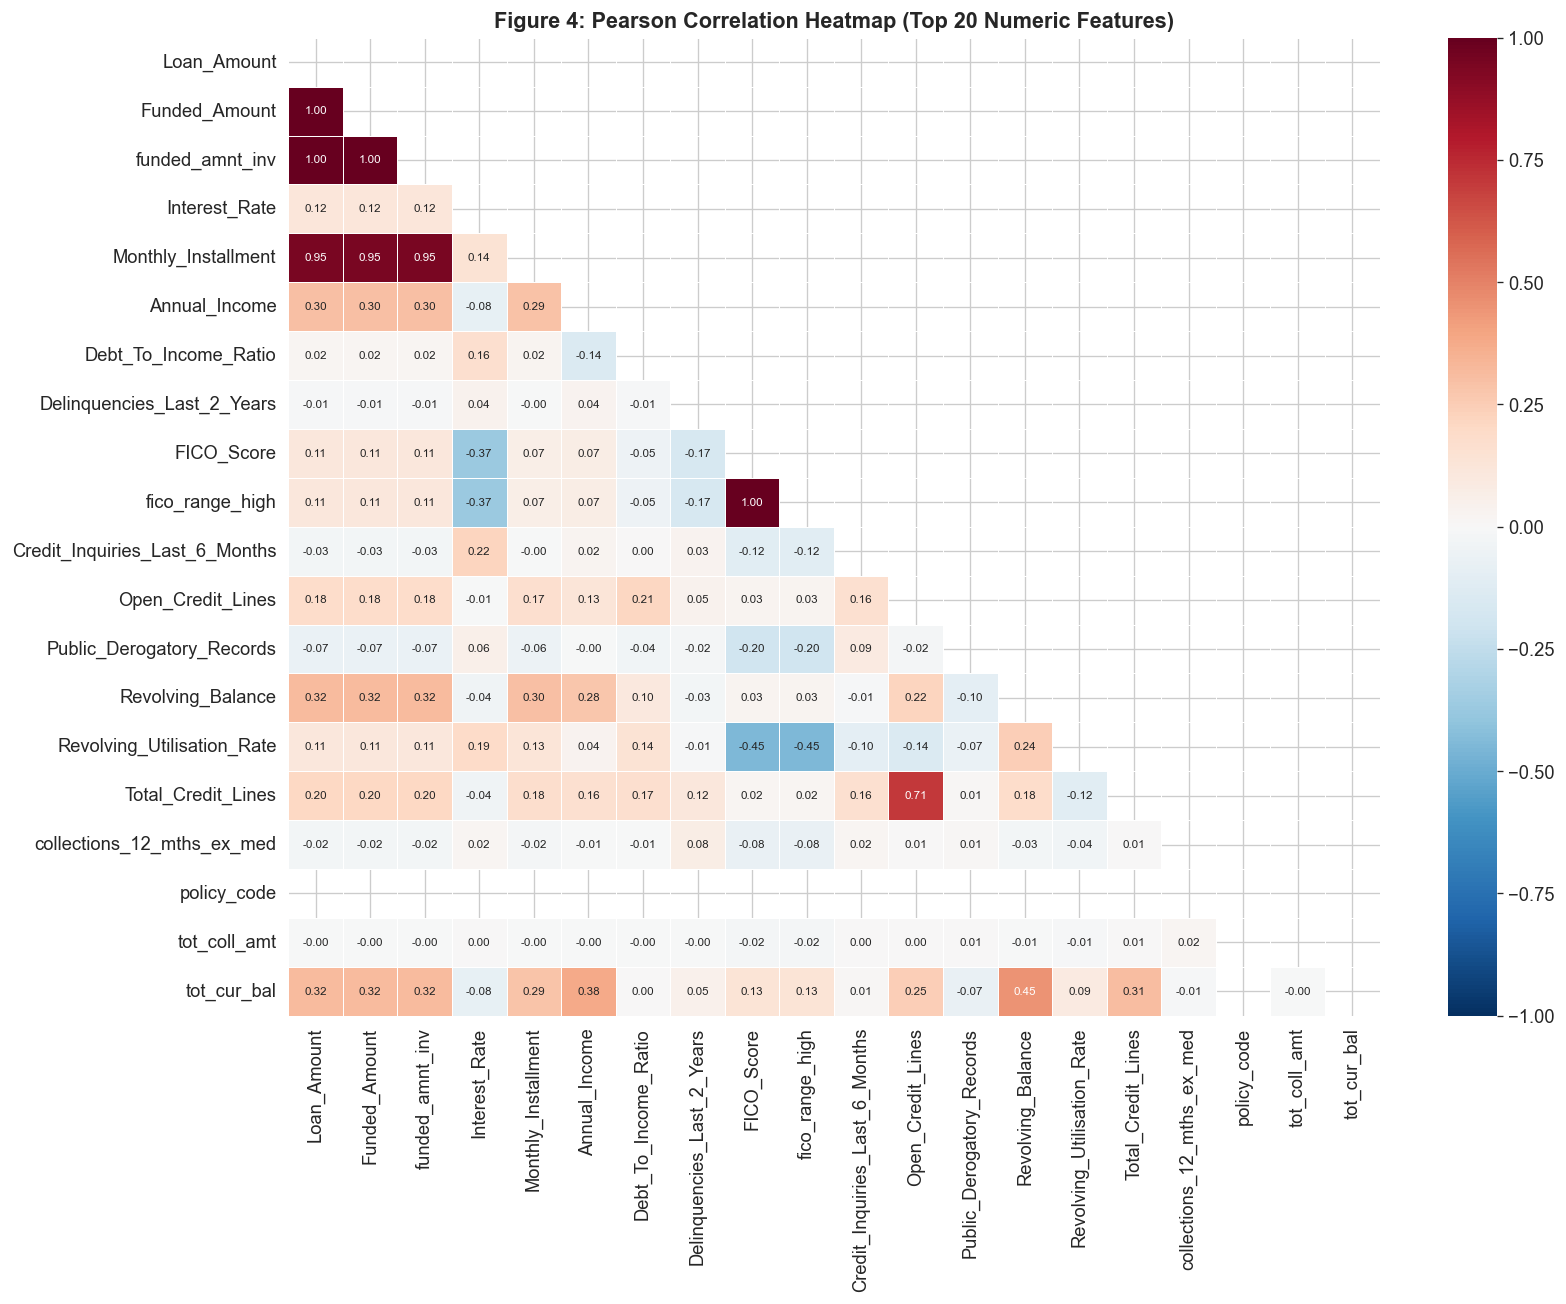

In [11]:
# ================================================================
# STEP 4 -- EXPLORATORY DATA ANALYSIS
# ================================================================
eda_df = df.copy()
for col in ['Interest_Rate','Revolving_Utilisation_Rate']:
    if col in eda_df.columns:
        eda_df[col] = eda_df[col].apply(clean_percent)

# Table 4: Descriptive statistics
key_num = [c for c in ['Loan_Amount','Interest_Rate','Annual_Income',
           'Debt_To_Income_Ratio','FICO_Score','Revolving_Utilisation_Rate',
           'Revolving_Balance','Monthly_Installment'] if c in eda_df.columns]
desc = eda_df[key_num].describe().T
desc['skewness'] = eda_df[key_num].skew()
print('Table 4: Descriptive Statistics for Key Numeric Features')
display(desc.round(2))

# Figure 2: Feature distributions by default status
fig, axes = plt.subplots(2,4,figsize=(18,9))
axes = axes.ravel()
colours = {0:'steelblue',1:'tomato'}; labels = {0:'Fully Paid',1:'Default'}
for idx,col in enumerate(key_num[:8]):
    for cls in [0,1]:
        subset = eda_df[eda_df['Default']==cls][col].dropna()
        if col in ['Annual_Income','Revolving_Balance']:
            subset = np.log1p(subset); xl = f'log({col})'
        else: xl = col
        axes[idx].hist(subset,bins=50,alpha=0.55,color=colours[cls],
                       label=labels[cls],density=True)
    axes[idx].set_title(col.replace('_',' '),fontsize=9,fontweight='bold')
    axes[idx].set_xlabel(xl,fontsize=8); axes[idx].legend(fontsize=7)
    axes[idx].grid(alpha=0.3)
fig.suptitle('Figure 2: Feature Distributions by Default Status',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_distributions.png',dpi=150,bbox_inches='tight')
plt.show()

# Figure 3: Default rate by Credit Grade and Loan Term
fig, axes = plt.subplots(1,2,figsize=(14,5))
if 'Credit_Grade' in eda_df.columns:
    gd = eda_df.groupby('Credit_Grade')['Default'].mean().sort_index()*100
    bars = axes[0].bar(gd.index,gd.values,
                       color=plt.cm.RdYlGn_r(np.linspace(0.2,0.9,len(gd))),
                       edgecolor='white')
    for bar,v in zip(bars,gd.values):
        axes[0].text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.3,
                     f'{v:.1f}%',ha='center',fontsize=9,fontweight='bold')
    axes[0].set_title('Figure 3a: Default Rate by Credit Grade',fontweight='bold')
    axes[0].set_xlabel('Credit Grade'); axes[0].set_ylabel('Default Rate (%)')
    axes[0].grid(axis='y',alpha=0.3)

if 'Loan_Term' in eda_df.columns:
    td = eda_df.groupby('Loan_Term')['Default'].mean()*100
    axes[1].bar(range(len(td)),td.values,color=['steelblue','tomato'],edgecolor='white')
    axes[1].set_xticks(range(len(td))); axes[1].set_xticklabels(td.index,rotation=20)
    for i,v in enumerate(td.values):
        axes[1].text(i,v+0.3,f'{v:.1f}%',ha='center',fontweight='bold')
    axes[1].set_title('Figure 3b: Default Rate by Loan Term',fontweight='bold')
    axes[1].set_xlabel('Loan Term'); axes[1].set_ylabel('Default Rate (%)')
    axes[1].grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.savefig('fig3_grade_term.png',dpi=150,bbox_inches='tight')
plt.show()

# Figure 4: Correlation heatmap
num_cols = eda_df.select_dtypes(include='number').columns[:20]
corr = eda_df[num_cols].corr()
fig,ax = plt.subplots(figsize=(14,11))
mask = np.triu(np.ones_like(corr,dtype=bool))
sns.heatmap(corr,mask=mask,annot=True,fmt='.2f',cmap='RdBu_r',
            center=0,vmin=-1,vmax=1,ax=ax,annot_kws={'size':7},linewidths=0.5)
ax.set_title('Figure 4: Pearson Correlation Heatmap (Top 20 Numeric Features)',
             fontweight='bold',fontsize=13)
plt.tight_layout()
plt.savefig('fig4_correlation.png',dpi=150,bbox_inches='tight')
plt.show()

## Step 5 — Feature Engineering

In [13]:
# ================================================================
# STEP 5 -- FEATURE ENGINEERING
# ================================================================
df_model = df.copy()

for col in ['Interest_Rate','Revolving_Utilisation_Rate','Bankcard_Utilisation_Rate']:
    if col in df_model.columns: df_model[col] = df_model[col].apply(clean_percent)

if 'Employment_Length' in df_model.columns:
    df_model['Employment_Length_Years'] = df_model['Employment_Length'].apply(clean_employment_length)
    df_model.drop(columns=['Employment_Length'],inplace=True)

if {'Issue_Date','Earliest_Credit_Line_Date'}.issubset(df_model.columns):
    issue    = pd.to_datetime(df_model['Issue_Date'],errors='coerce')
    earliest = pd.to_datetime(df_model['Earliest_Credit_Line_Date'],errors='coerce')
    df_model['Credit_Age_Months'] = ((issue-earliest).dt.days/30.44).clip(lower=0)
    df_model.drop(columns=['Issue_Date','Earliest_Credit_Line_Date'],inplace=True)

if 'Credit_Grade' in df_model.columns:
    df_model['Credit_Grade_Num'] = df_model['Credit_Grade'].map({'A':1,'B':2,'C':3,'D':4,'E':5,'F':6,'G':7})
    df_model.drop(columns=['Credit_Grade'],inplace=True)

if 'Loan_Term' in df_model.columns:
    df_model['Loan_Term_Months'] = df_model['Loan_Term'].apply(
        lambda x: int(re.search(r'\d+',str(x)).group()) if pd.notna(x) else np.nan)
    df_model.drop(columns=['Loan_Term'],inplace=True)

# Ratio features
if {'Loan_Amount','Annual_Income'}.issubset(df_model.columns):
    df_model['Loan_To_Income'] = df_model['Loan_Amount']/df_model['Annual_Income'].clip(lower=1)
if {'Monthly_Installment','Annual_Income'}.issubset(df_model.columns):
    df_model['Payment_To_Income'] = (df_model['Monthly_Installment']*12)/df_model['Annual_Income'].clip(lower=1)
if {'Revolving_Balance','Annual_Income'}.issubset(df_model.columns):
    df_model['RevBal_To_Income'] = df_model['Revolving_Balance']/df_model['Annual_Income'].clip(lower=1)

# Binary delinquency indicators
if 'Delinquencies_Last_2_Years' in df_model.columns:
    df_model['Has_Recent_Delinq'] = (df_model['Delinquencies_Last_2_Years']>0).astype(int)
if 'Public_Record_Bankruptcies' in df_model.columns:
    df_model['Has_Bankruptcy'] = (df_model['Public_Record_Bankruptcies']>0).astype(int)

# Log-transform skewed columns
for col in ['Annual_Income','Revolving_Balance','Loan_Amount']:
    if col in df_model.columns:
        upper = df_model[col].quantile(0.999)
        df_model[col] = np.log1p(df_model[col].clip(upper=upper))

# Table 5: Engineered features
eng_table = pd.DataFrame({
    'Feature':['Credit_Age_Months','Loan_To_Income','Payment_To_Income',
               'RevBal_To_Income','Has_Recent_Delinq','Has_Bankruptcy',
               'Credit_Grade_Num','Loan_Term_Months','Employment_Length_Years'],
    'Type':['Derived','Ratio','Ratio','Ratio','Binary','Binary','Ordinal','Numeric','Numeric'],
    'Description':['Months from earliest credit line to issue',
                   'Loan / Annual Income','(Installment×12) / Annual Income',
                   'Revolving Balance / Annual Income',
                   '1 if any delinquency in last 2 years',
                   '1 if any bankruptcy on record',
                   'A=1 … G=7 (ordinal risk scale)',
                   'Term as integer (36 or 60)',
                   'Employment length in years']
})
print('Table 5: Engineered Features')
display(eng_table)
print(f'Feature matrix shape: {df_model.shape}')

Table 5: Engineered Features


,Feature,Type,Description
0,Credit_Age_Months,Derived,Months from earliest credit line to issue
1,Loan_To_Income,Ratio,Loan / Annual Income
2,Payment_To_Income,Ratio,(Installment×12) / Annual Income
3,RevBal_To_Income,Ratio,Revolving Balance / Annual Income
4,Has_Recent_Delinq,Binary,1 if any delinquency in last 2 years
5,Has_Bankruptcy,Binary,1 if any bankruptcy on record
6,Credit_Grade_Num,Ordinal,A=1 … G=7 (ordinal risk scale)
7,Loan_Term_Months,Numeric,Term as integer (36 or 60)
8,Employment_Length_Years,Numeric,Employment length in years


Feature matrix shape: (611585, 79)


---
# WEEK 4 — Baseline Modelling
## Step 6 — Train/Validation/Test Split (70/15/15)

In [15]:
# ================================================================
# STEP 6 -- STRATIFIED 70/15/15 SPLIT
# ================================================================
X = df_model.drop(columns=['Default'])
y = df_model['Default'].astype(int)
X = X.drop(columns=X.columns[X.isna().all()].tolist())

X_train,X_temp,y_train,y_temp = train_test_split(X,y,test_size=0.30,stratify=y,random_state=SEED)
X_val,X_test,y_val,y_test     = train_test_split(X_temp,y_temp,test_size=0.50,stratify=y_temp,random_state=SEED)

print('Table 6: Dataset Split Summary')
display(pd.DataFrame({
    'Split':['Train (70%)','Validation (15%)','Test (15%)'],
    'Samples':[len(X_train),len(X_val),len(X_test)],
    'Defaults':[int(y_train.sum()),int(y_val.sum()),int(y_test.sum())],
    'Default_Rate':[f'{y_train.mean():.3f}',f'{y_val.mean():.3f}',f'{y_test.mean():.3f}']
}))

Table 6: Dataset Split Summary


,Split,Samples,Defaults,Default_Rate
0,Train (70%),428109,90420,0.211
1,Validation (15%),91738,19376,0.211
2,Test (15%),91738,19375,0.211


## Step 7 — Preprocessing Pipeline

In [17]:
# ================================================================
# STEP 7 -- SKLEARN PREPROCESSING PIPELINE
# ================================================================
num_feats = X_train.select_dtypes(include=['number','bool']).columns.tolist()
cat_feats = [c for c in X_train.columns if c not in num_feats]

num_pipe = Pipeline([('imp',SimpleImputer(strategy='median')),
                     ('scl',StandardScaler())])
cat_pipe = Pipeline([('imp',SimpleImputer(strategy='most_frequent')),
                     ('ohe',OneHotEncoder(handle_unknown='ignore',sparse_output=False,
                                         dtype=np.float32,max_categories=30))])
preprocessor = ColumnTransformer([('num',num_pipe,num_feats),
                                   ('cat',cat_pipe,cat_feats)],
                                   remainder='drop',sparse_threshold=0.0,
                                   verbose_feature_names_out=False)

X_train_p = preprocessor.fit_transform(X_train).astype(np.float32)
X_val_p   = preprocessor.transform(X_val).astype(np.float32)
X_test_p  = preprocessor.transform(X_test).astype(np.float32)
feature_names = np.array(preprocessor.get_feature_names_out())

print(f'Numeric features    : {len(num_feats)}')
print(f'Categorical features: {len(cat_feats)}')
print(f'Total processed features: {X_train_p.shape[1]}')
print(f'Training matrix shape: {X_train_p.shape}')

Numeric features    : 62
Categorical features: 15
Total processed features: 295
Training matrix shape: (428109, 295)


## Step 8 — OLS Feature Selection

OLS selected 21 features (p < 0.05)

Table 7: Top 15 OLS-Selected Features


,Feature,OLS_Coeff,P_Value,Norm_Coeff
0,emp_title_Driver,0.0758,0.0087,0.0
1,emp_title_Owner,0.0729,0.0043,0.0
2,Bankcard_Utilisation_Rate,0.0145,0.0132,0.0
3,Annual_Income,-0.0121,0.0011,0.0
4,Credit_Inquiries_Last_6_Months,0.0136,0.0000,0.0
5,num_rev_accts,-0.0729,0.0169,0.0
6,Loan_Amount,0.0266,0.0001,0.0
7,Loan_Term_Months,0.0826,0.0000,0.0
8,Debt_To_Income_Ratio,0.0274,0.0000,0.0
9,tot_hi_cred_lim,0.0140,0.0350,0.0


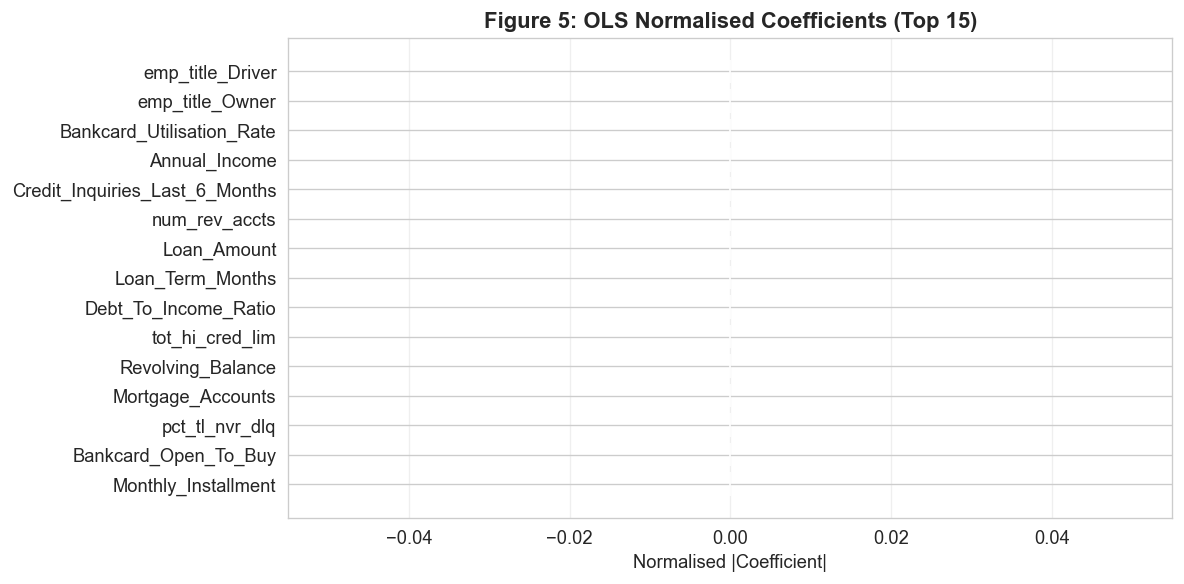

In [19]:
# ================================================================
# STEP 8 -- OLS FEATURE SELECTION
# ================================================================
N_OLS = min(30_000, X_train_p.shape[0])
MAX_OLS = min(200, X_train_p.shape[1])
P_CUT, MIN_SEL, MAX_SEL = 0.05, 15, 80

rng = np.random.default_rng(SEED)
sidx = rng.choice(X_train_p.shape[0], size=N_OLS, replace=False)
X_os = X_train_p[sidx]; y_os = y_train.iloc[sidx].astype(float).values

var = X_os.var(axis=0)
nc_idx = np.where(var>1e-8)[0]
ols_idx = nc_idx[np.argsort(var[nc_idx])[::-1]][:MAX_OLS]

X_ols   = sm.add_constant(X_os[:,ols_idx])
result  = sm.OLS(y_os, X_ols).fit()
coefs   = result.params[1:]; pvals = result.pvalues[1:]
ncoefs  = np.abs(coefs)/(np.abs(coefs).max()+1e-12)

ols_df = pd.DataFrame({'Feature':feature_names[ols_idx],
                        'OLS_Coeff':coefs.round(4),
                        'P_Value':pvals.round(4),
                        'Norm_Coeff':ncoefs.round(4)
                       }).sort_values('Norm_Coeff',ascending=False)

sel_df = ols_df[ols_df['P_Value']<P_CUT]
if len(sel_df)<MIN_SEL: sel_df = ols_df.head(MIN_SEL)
if len(sel_df)>MAX_SEL: sel_df = sel_df.head(MAX_SEL)

selected_features = sel_df['Feature'].tolist()
sel_col_idx = np.where(np.isin(feature_names,selected_features))[0]

X_train_s = X_train_p[:,sel_col_idx]
X_val_s   = X_val_p[:,sel_col_idx]
X_test_s  = X_test_p[:,sel_col_idx]
N_INPUT   = X_train_s.shape[1]

print(f'OLS selected {len(selected_features)} features (p < {P_CUT})')
print('\nTable 7: Top 15 OLS-Selected Features')
display(sel_df.head(15).reset_index(drop=True))

# Figure 5: OLS feature importance
top15 = sel_df.head(15)
fig,ax = plt.subplots(figsize=(10,5))
cols = ['tomato' if c>0 else 'steelblue' for c in top15['OLS_Coeff']]
ax.barh(top15['Feature'][::-1],top15['Norm_Coeff'][::-1],color=cols[::-1])
ax.set_title('Figure 5: OLS Normalised Coefficients (Top 15)',fontweight='bold')
ax.set_xlabel('Normalised |Coefficient|'); ax.grid(axis='x',alpha=0.3)
plt.tight_layout(); plt.savefig('fig5_ols.png',dpi=150,bbox_inches='tight'); plt.show()

## Steps 9–10 — Class Imbalance Strategy & Baseline Models

In [21]:
# ================================================================
# STEP 9 -- CLASS IMBALANCE: SMOTE vs CLASS WEIGHTS
# ================================================================
imb_rows = []
cw_lr = LogisticRegression(max_iter=1000,class_weight='balanced',random_state=SEED,n_jobs=-1)
cw_lr.fit(X_train_s,y_train)
cw_p = cw_lr.predict_proba(X_val_s)[:,1]
imb_rows.append({'Strategy':'Class-weighted LR',
                 'Val_ROC_AUC':round(roc_auc_score(y_val,cw_p),4),
                 'Val_PR_AUC':round(average_precision_score(y_val,cw_p),4),
                 'Val_F1':round(f1_score(y_val,cw_lr.predict(X_val_s),zero_division=0),4)})

if IMBLEARN_AVAILABLE:
    smote = SMOTE(random_state=SEED)
    X_sm,y_sm = smote.fit_resample(X_train_s,y_train)
    sm_lr = LogisticRegression(max_iter=1000,random_state=SEED,n_jobs=-1)
    sm_lr.fit(X_sm,y_sm)
    sm_p = sm_lr.predict_proba(X_val_s)[:,1]
    imb_rows.append({'Strategy':'SMOTE + LR',
                     'Val_ROC_AUC':round(roc_auc_score(y_val,sm_p),4),
                     'Val_PR_AUC':round(average_precision_score(y_val,sm_p),4),
                     'Val_F1':round(f1_score(y_val,sm_lr.predict(X_val_s),zero_division=0),4)})
    X_train_sm,y_train_sm = X_sm,y_sm
else:
    mi = np.where(y_train==1)[0]; ma = np.where(y_train==0)[0]
    rs = np.concatenate([ma,np.tile(mi,len(ma)//len(mi))]); np.random.shuffle(rs)
    X_train_sm = X_train_s[rs]; y_train_sm = y_train.iloc[rs].values
    print('Fallback oversampling used.')

print('Table 8: Class Imbalance Strategy Comparison')
display(pd.DataFrame(imb_rows))

# ================================================================
# STEP 10 -- BASELINE MODELS
# ================================================================
models = {}; metrics = []

# Logistic Regression
print('\nTraining Logistic Regression...')
lr = LogisticRegression(max_iter=1000,class_weight='balanced',random_state=SEED,n_jobs=-1)
lr.fit(X_train_s,y_train)
models['Logistic Regression'] = lr
metrics.append(evaluate_model('Logistic Regression',lr,
    X_train_s,y_train,X_val_s,y_val,X_test_s,y_test))
print('  Done.')

# Random Forest
print('Training Random Forest...')
rf = RandomForestClassifier(n_estimators=200,max_depth=12,min_samples_leaf=50,
                             class_weight='balanced_subsample',random_state=SEED,n_jobs=-1)
rf.fit(X_train_s,y_train)
models['Random Forest'] = rf
metrics.append(evaluate_model('Random Forest',rf,
    X_train_s,y_train,X_val_s,y_val,X_test_s,y_test))
print('  Done.')

baseline_all  = pd.concat(metrics,ignore_index=True)
baseline_test = baseline_all[baseline_all['Split']=='Test']
print('\nTable 9: Baseline Models — Test Set Performance')
display(baseline_test[['Model','Accuracy','Precision','Recall','F1',
                         'ROC_AUC','PR_AUC','MCC','Log_Loss','Brier']].round(4))

Table 8: Class Imbalance Strategy Comparison


,Strategy,Val_ROC_AUC,Val_PR_AUC,Val_F1
0,Class-weighted LR,0.7055,0.3875,0.4358
1,SMOTE + LR,0.7043,0.3873,0.4362



Training Logistic Regression...
  Done.
Training Random Forest...
  Done.

Table 9: Baseline Models — Test Set Performance


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,MCC,Log_Loss,Brier
2,Logistic Regression,0.6642,0.3411,0.6333,0.4434,0.7104,0.3965,0.2556,0.6245,0.2167
5,Random Forest,0.6769,0.3486,0.6098,0.4436,0.7133,0.4026,0.2577,0.6084,0.2100


---
# WEEK 5 — Deep Neural Network
## Step 11 — DNN Architecture

### Design Rationale
| Component | Choice | Why it beats MLPClassifier |
|-----------|--------|---------------------------|
| Residual connections | Skip every 2 layers | Prevents vanishing gradients in deep networks |
| Batch Normalisation | After every linear layer | Stable activations → higher LR possible |
| Focal Loss (γ=2) | Replaces BCE | Down-weights easy negatives → focuses on hard defaults |
| WeightedRandomSampler | Class-balanced batches | Every mini-batch sees ~50/50 class split |
| CosineAnnealingWarmRestarts | LR schedule | Escapes local minima; finds better convergence |
| AdamW | Optimiser | Decoupled L2 weight decay → less overfitting |
| Dropout (p=0.3) | Per residual block | Regularisation against minority-class overfitting |
| Kaiming init | Weight init | Optimal for GELU/ReLU activations |
| FeatureAttention | Soft gate (v2) | Learns which features matter → better generalisation |
| Mixup augmentation | Training (v2) | Interpolates samples → reduces overfitting |

In [23]:
# ================================================================
# STEP 11 -- DNN ARCHITECTURE COMPONENTS
# ================================================================
if not TORCH_AVAILABLE:
    raise RuntimeError('Install PyTorch: pip install torch')

# ── Focal Loss ────────────────────────────────────────────────
class FocalLoss(nn.Module):
    """
    FL(p_t) = -alpha_t * (1-p_t)^gamma * log(p_t)
    gamma=2 focuses training on hard misclassified default cases.
    """
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma
    def forward(self, logits, targets):
        bce    = F.binary_cross_entropy_with_logits(logits,targets,reduction='none')
        p_t    = torch.exp(-bce)
        a_t    = self.alpha*targets + (1-self.alpha)*(1-targets)
        return (a_t * (1-p_t)**self.gamma * bce).mean()

# ── Residual Block ────────────────────────────────────────────
class ResidualBlock(nn.Module):
    """
    F(x) = Linear→BN→GELU→Dropout→Linear→BN
    out  = GELU(F(x) + skip(x))
    skip = Identity if dims match, else Linear projection.
    """
    def __init__(self, in_dim, out_dim, dropout=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(in_dim, out_dim), nn.BatchNorm1d(out_dim), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(out_dim, out_dim), nn.BatchNorm1d(out_dim))
        self.skip = nn.Linear(in_dim,out_dim) if in_dim!=out_dim else nn.Identity()
        self.act  = nn.GELU()
    def forward(self, x):
        return self.act(self.block(x) + self.skip(x))

# ── Feature Attention (v2) ────────────────────────────────────
class FeatureAttention(nn.Module):
    """Learns a per-feature soft weight: out = x * sigmoid(W*x+b)"""
    def __init__(self, n): super().__init__(); self.w = nn.Sequential(nn.Linear(n,n),nn.Sigmoid())
    def forward(self, x): return x * self.w(x)

# ── DNN v1 ────────────────────────────────────────────────────
class LoanDefaultDNN(nn.Module):
    """InputProj → [ResidualBlock × N] → OutputHead"""
    def __init__(self, n_input, hidden_sizes=None, dropout=0.3):
        super().__init__()
        if hidden_sizes is None: hidden_sizes=[512,256,128,64,32]
        self.input_proj = nn.Sequential(
            nn.Linear(n_input,hidden_sizes[0]),nn.BatchNorm1d(hidden_sizes[0]),nn.GELU())
        self.res_blocks = nn.ModuleList([
            ResidualBlock(hidden_sizes[i],hidden_sizes[i+1],dropout)
            for i in range(len(hidden_sizes)-1)])
        self.output_head = nn.Linear(hidden_sizes[-1],1)
        self._init()
    def _init(self):
        for m in self.modules():
            if isinstance(m,nn.Linear):
                nn.init.kaiming_normal_(m.weight,nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m,nn.BatchNorm1d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
    def forward(self, x):
        x = self.input_proj(x)
        for b in self.res_blocks: x = b(x)
        return self.output_head(x).squeeze(-1)

# ── DNN v2 (with FeatureAttention) ────────────────────────────
class LoanDefaultDNN_v2(nn.Module):
    """FeatureAttention → InputProj → [ResidualBlock × N] → OutputHead"""
    def __init__(self, n_input, hidden_sizes=None, dropout=0.2):
        super().__init__()
        if hidden_sizes is None: hidden_sizes=[512,512,256,128,64,32]
        self.attn = FeatureAttention(n_input)
        self.input_proj = nn.Sequential(
            nn.Linear(n_input,hidden_sizes[0]),nn.BatchNorm1d(hidden_sizes[0]),nn.GELU())
        self.res_blocks = nn.ModuleList([
            ResidualBlock(hidden_sizes[i],hidden_sizes[i+1],dropout)
            for i in range(len(hidden_sizes)-1)])
        self.output_head = nn.Linear(hidden_sizes[-1],1)
        self._init()
    def _init(self):
        for m in self.modules():
            if isinstance(m,nn.Linear):
                nn.init.kaiming_normal_(m.weight,nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m,nn.BatchNorm1d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
    def forward(self, x):
        x = self.attn(x)
        x = self.input_proj(x)
        for b in self.res_blocks: x = b(x)
        return self.output_head(x).squeeze(-1)

# ── sklearn-compatible wrapper ────────────────────────────────
class TorchDNNWrapper:
    def __init__(self, model, device, threshold=0.5):
        self.model,self.device,self.threshold = model,device,threshold
    def predict_proba(self, X):
        self.model.eval()
        with torch.no_grad():
            p = torch.sigmoid(self.model(torch.tensor(X,dtype=torch.float32).to(self.device)))
        return np.column_stack([1-p.cpu().numpy(), p.cpu().numpy()])
    def predict(self, X):
        return (self.predict_proba(X)[:,1]>=self.threshold).astype(int)

# ── Training loop (shared by v1 and v2) ──────────────────────
def train_dnn(X_tr, y_tr, X_val, y_val, n_input, model_cls=LoanDefaultDNN,
              hidden_sizes=None, dropout=0.3, lr=3e-4, weight_decay=1e-4,
              focal_alpha=0.25, focal_gamma=2.0,
              label_smoothing=0.0, mixup_alpha=0.0,
              batch_size=2048, n_epochs=60, patience=8, device=None, verbose=True):
    if device is None: device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if hidden_sizes is None: hidden_sizes=[512,256,128,64,32]

    cc = np.bincount(y_tr.astype(int)); cw = 1.0/cc; sw = cw[y_tr.astype(int)]
    sampler = WeightedRandomSampler(torch.tensor(sw,dtype=torch.float32),len(y_tr),True)
    tds = TensorDataset(torch.tensor(X_tr,dtype=torch.float32),torch.tensor(y_tr.astype(np.float32)))
    vds = TensorDataset(torch.tensor(X_val,dtype=torch.float32),torch.tensor(y_val.astype(np.float32)))
    tl  = DataLoader(tds,batch_size=batch_size,sampler=sampler)
    vl  = DataLoader(vds,batch_size=4096,shuffle=False)

    model     = model_cls(n_input,hidden_sizes,dropout).to(device)
    criterion = FocalLoss(focal_alpha,focal_gamma)
    optimizer = AdamW(model.parameters(),lr=lr,weight_decay=weight_decay)
    scheduler = CosineAnnealingWarmRestarts(optimizer,T_0=10,T_mult=2,eta_min=1e-6)

    hist = {'epoch':[],'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[],'val_auc':[]}
    best_auc,best_state,pat = 0.0,None,0

    for epoch in range(1,n_epochs+1):
        model.train()
        tr_loss,tr_cor,tr_tot = 0.0,0,0
        for Xb,yb in tl:
            Xb,yb = Xb.to(device),yb.to(device)
            ys = yb*(1-label_smoothing)+0.5*label_smoothing
            if mixup_alpha>0 and np.random.rand()<0.5:
                lam=np.random.beta(mixup_alpha,mixup_alpha); idx=torch.randperm(Xb.size(0))
                Xb=lam*Xb+(1-lam)*Xb[idx]; ys=lam*ys+(1-lam)*ys[idx]
            optimizer.zero_grad()
            logits=model(Xb); loss=criterion(logits,ys); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(),1.0); optimizer.step()
            tr_loss+=loss.item(); preds=(torch.sigmoid(logits)>=0.5).float()
            tr_cor+=(preds==yb).sum().item(); tr_tot+=len(yb)
        scheduler.step(epoch)
        avg_tr=tr_loss/len(tl); tr_acc=tr_cor/tr_tot

        model.eval(); vl_losses,vl_probs,vl_labels,vl_cor,vl_tot=[],[],[],0,0
        with torch.no_grad():
            for Xb,yb in vl:
                Xb,yb=Xb.to(device),yb.to(device); logits=model(Xb)
                vl_losses.append(criterion(logits,yb).item()); pr=torch.sigmoid(logits)
                vl_probs.extend(pr.cpu().numpy()); vl_labels.extend(yb.cpu().numpy())
                vl_cor+=((pr>=0.5).float()==yb).sum().item(); vl_tot+=len(yb)
        avg_vl=np.mean(vl_losses); vl_auc=roc_auc_score(vl_labels,vl_probs); vl_acc=vl_cor/vl_tot

        hist['epoch'].append(epoch); hist['train_loss'].append(avg_tr)
        hist['val_loss'].append(avg_vl); hist['train_acc'].append(tr_acc)
        hist['val_acc'].append(vl_acc); hist['val_auc'].append(vl_auc)

        if verbose and (epoch%5==0 or epoch==1):
            print(f'Epoch {epoch:3d}/{n_epochs} | Train Loss:{avg_tr:.4f} Acc:{tr_acc:.4f}'
                  f' | Val Loss:{avg_vl:.4f} Acc:{vl_acc:.4f} AUC:{vl_auc:.4f}')
        if vl_auc>best_auc:
            best_auc=vl_auc; best_state={k:v.cpu().clone() for k,v in model.state_dict().items()}; pat=0
        else:
            pat+=1
            if pat>=patience: print(f'  Early stop epoch {epoch}. Best AUC:{best_auc:.4f}'); break

    model.load_state_dict({k:v.to(device) for k,v in best_state.items()})
    print(f'\n★ Best Val ROC-AUC: {best_auc:.4f}')
    return model, hist

# Print architecture
demo = LoanDefaultDNN(N_INPUT)
print(demo)
print(f'\nTotal parameters: {sum(p.numel() for p in demo.parameters()):,}')

LoanDefaultDNN(
  (input_proj): Sequential(
    (0): Linear(in_features=21, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): GELU(approximate='none')
  )
  (res_blocks): ModuleList(
    (0): ResidualBlock(
      (block): Sequential(
        (0): Linear(in_features=512, out_features=256, bias=True)
        (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.3, inplace=False)
        (4): Linear(in_features=256, out_features=256, bias=True)
        (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (skip): Linear(in_features=512, out_features=256, bias=True)
      (act): GELU(approximate='none')
    )
    (1): ResidualBlock(
      (block): Sequential(
        (0): Linear(in_features=256, out_features=128, bias=True)
        (1): Batch

## Step 12 — Train DNN v1 (Residual Blocks, OLS Features)

  Training DNN v1 (Residual Blocks + Focal Loss)
Epoch   1/60 | Train Loss:0.0774 Acc:0.5494 | Val Loss:0.0604 Acc:0.7897 AUC:0.6990
Epoch   5/60 | Train Loss:0.0650 Acc:0.5640 | Val Loss:0.0603 Acc:0.7922 AUC:0.7149
Epoch  10/60 | Train Loss:0.0647 Acc:0.5652 | Val Loss:0.0590 Acc:0.7932 AUC:0.7187
Epoch  15/60 | Train Loss:0.0641 Acc:0.5730 | Val Loss:0.0607 Acc:0.7909 AUC:0.7213
Epoch  20/60 | Train Loss:0.0635 Acc:0.5777 | Val Loss:0.0589 Acc:0.7931 AUC:0.7226
Epoch  25/60 | Train Loss:0.0629 Acc:0.5842 | Val Loss:0.0598 Acc:0.7924 AUC:0.7223
  Early stop epoch 25. Best AUC:0.7226

★ Best Val ROC-AUC: 0.7226

Table 10: DNN v1 Training Progress (every 5 epochs)


,Epoch,Train_Loss,Val_Loss,Train_Acc,Val_Acc,Val_AUC
4,5,0.0650,0.0603,0.5640,0.7922,0.7149
9,10,0.0647,0.0590,0.5652,0.7932,0.7187
14,15,0.0641,0.0607,0.5730,0.7909,0.7213
19,20,0.0635,0.0589,0.5777,0.7931,0.7226
24,25,0.0629,0.0598,0.5842,0.7924,0.7223


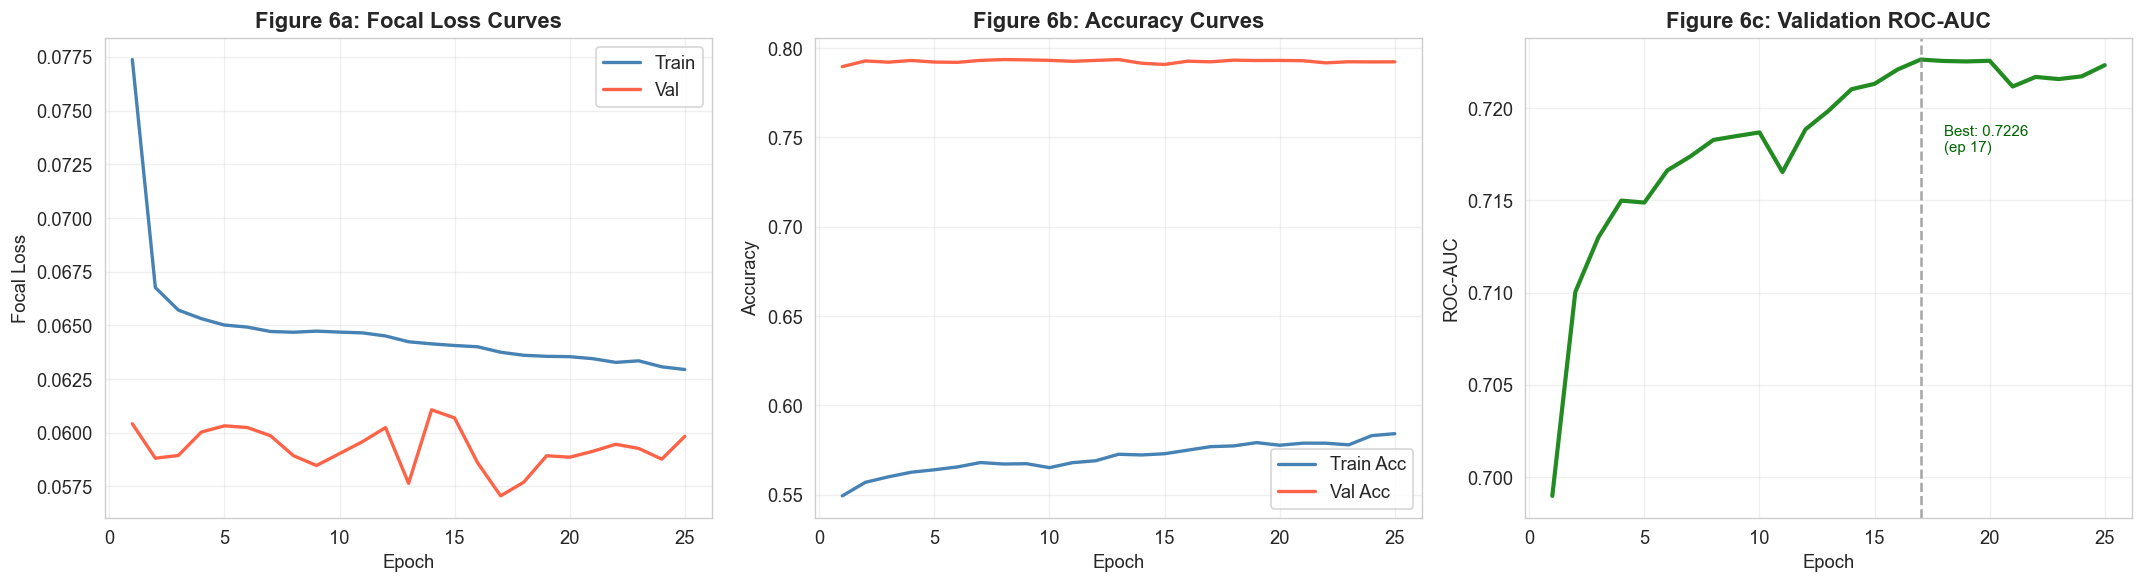

In [25]:
# ================================================================
# STEP 12 -- TRAIN DNN v1
# ================================================================
print('='*65)
print('  Training DNN v1 (Residual Blocks + Focal Loss)')
print('='*65)

dnn1_raw, dnn1_hist = train_dnn(
    X_train_s, y_train.values, X_val_s, y_val.values,
    n_input=N_INPUT, model_cls=LoanDefaultDNN,
    hidden_sizes=[512,256,128,64,32], dropout=0.3,
    lr=3e-4, weight_decay=1e-4,
    focal_alpha=0.25, focal_gamma=2.0,
    label_smoothing=0.0, mixup_alpha=0.0,
    batch_size=2048, n_epochs=60, patience=8,
    device=DEVICE, verbose=True)

dnn1_wrap = TorchDNNWrapper(dnn1_raw, DEVICE)
models['Deep Neural Network'] = dnn1_wrap
metrics.append(evaluate_model('Deep Neural Network', dnn1_wrap,
    X_train_s,y_train,X_val_s,y_val,X_test_s,y_test))

# Table 10: Training progress
ep_sum = pd.DataFrame({
    'Epoch': dnn1_hist['epoch'],
    'Train_Loss': [round(x,4) for x in dnn1_hist['train_loss']],
    'Val_Loss':   [round(x,4) for x in dnn1_hist['val_loss']],
    'Train_Acc':  [round(x,4) for x in dnn1_hist['train_acc']],
    'Val_Acc':    [round(x,4) for x in dnn1_hist['val_acc']],
    'Val_AUC':    [round(x,4) for x in dnn1_hist['val_auc']]
})
print('\nTable 10: DNN v1 Training Progress (every 5 epochs)')
display(ep_sum[ep_sum['Epoch']%5==0])

# Figure 6: Training curves
fig,axes = plt.subplots(1,3,figsize=(18,5))
ep = dnn1_hist['epoch']
axes[0].plot(ep,dnn1_hist['train_loss'],label='Train',color='steelblue',lw=2)
axes[0].plot(ep,dnn1_hist['val_loss'],label='Val',color='tomato',lw=2)
axes[0].set_title('Figure 6a: Focal Loss Curves',fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Focal Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep,dnn1_hist['train_acc'],label='Train Acc',color='steelblue',lw=2)
axes[1].plot(ep,dnn1_hist['val_acc'],label='Val Acc',color='tomato',lw=2)
axes[1].set_title('Figure 6b: Accuracy Curves',fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep,dnn1_hist['val_auc'],color='forestgreen',lw=2.5)
best_e=ep[int(np.argmax(dnn1_hist['val_auc']))]; best_v=max(dnn1_hist['val_auc'])
axes[2].axvline(x=best_e,color='gray',ls='--',alpha=0.7)
axes[2].annotate(f'Best: {best_v:.4f}\n(ep {best_e})',xy=(best_e,best_v),
                 xytext=(best_e+1,best_v-0.005),fontsize=9,color='darkgreen')
axes[2].set_title('Figure 6c: Validation ROC-AUC',fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('ROC-AUC'); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('fig6_dnn1_training.png',dpi=150,bbox_inches='tight'); plt.show()

## Step 13 — Hyperparameter Tuning (Optuna Bayesian Search)

In [27]:
# ================================================================
# STEP 13 -- OPTUNA HYPERPARAMETER TUNING
# SKIP_TUNING = True  →  skip tuning, move straight to Week 6
# SKIP_TUNING = False →  run 30 Bayesian trials (~30–60 min on CPU)
# ================================================================
SKIP_TUNING = True   # ← change to False only if you have 30+ min to spare

if OPTUNA_AVAILABLE and not SKIP_TUNING:
    def objective(trial):
        n_l = trial.suggest_int('n_layers', 3, 6)
        fd  = trial.suggest_categorical('first_dim', [256, 512, 1024])
        do  = trial.suggest_float('dropout', 0.1, 0.5)
        lr_ = trial.suggest_float('lr', 1e-4, 1e-3, log=True)
        wd_ = trial.suggest_float('wd', 1e-5, 1e-3, log=True)
        fg  = trial.suggest_float('f_gamma', 1.0, 3.0)
        fa  = trial.suggest_float('f_alpha', 0.15, 0.40)
        bs  = trial.suggest_categorical('batch_size', [1024, 2048, 4096])
        hs  = [max(32, fd // (2**i)) for i in range(n_l)]
        try:
            _, h = train_dnn(
                X_tr=X_train_s, y_tr=y_train.values,
                X_val=X_val_s,  y_val=y_val.values,
                n_input=N_INPUT, model_cls=LoanDefaultDNN,
                hidden_sizes=hs, dropout=do,
                lr=lr_, weight_decay=wd_,
                focal_alpha=fa, focal_gamma=fg,
                label_smoothing=0.0, mixup_alpha=0.0,
                batch_size=bs, n_epochs=25, patience=5,
                device=DEVICE, verbose=False)
            return max(h['val_auc'])
        except Exception:
            return 0.0

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=30, show_progress_bar=True)
    bp = study.best_params
    print(f'Best Val AUC: {study.best_value:.4f}')
    print('Best hyperparameters:')
    display(pd.DataFrame([bp]))

    best_hs = [max(32, bp['first_dim'] // (2**i)) for i in range(bp['n_layers'])]
    print(f'\nRetraining tuned DNN with hidden sizes: {best_hs}')
    dnn_t_raw, _ = train_dnn(
        X_tr=X_train_s, y_tr=y_train.values,
        X_val=X_val_s,  y_val=y_val.values,
        n_input=N_INPUT, model_cls=LoanDefaultDNN,
        hidden_sizes=best_hs, dropout=bp['dropout'],
        lr=bp['lr'], weight_decay=bp['wd'],
        focal_alpha=bp['f_alpha'], focal_gamma=bp['f_gamma'],
        label_smoothing=0.0, mixup_alpha=0.0,
        batch_size=bp['batch_size'], n_epochs=80, patience=10,
        device=DEVICE, verbose=True)
    dnn_t_wrap = TorchDNNWrapper(dnn_t_raw, DEVICE)
    models['DNN (Tuned)'] = dnn_t_wrap
    metrics.append(evaluate_model('DNN (Tuned)', dnn_t_wrap,
        X_train_s, y_train, X_val_s, y_val, X_test_s, y_test))
    print('✓ Tuned DNN added to comparison.')

elif SKIP_TUNING:
    print('Step 13 skipped (SKIP_TUNING=True). Proceeding to Week 6.')
    print('Set SKIP_TUNING=False above and re-run this cell to enable Bayesian search.')
else:
    print('Optuna not installed. Run: pip install optuna')


Step 13 skipped (SKIP_TUNING=True). Proceeding to Week 6.
Set SKIP_TUNING=False above and re-run this cell to enable Bayesian search.


---
# WEEK 6 — Final Evaluation, SHAP & Improvements
## Step 14 — Full Model Comparison (Train / Val / Test)

In [29]:
# ================================================================
# STEP 14 -- COMPREHENSIVE MODEL COMPARISON (Train / Val / Test)
# ================================================================
all_metrics = pd.concat(metrics, ignore_index=True)
metric_cols = ['Model','Split','Accuracy','Precision','Recall','Specificity',
               'F1','Balanced_Acc','ROC_AUC','PR_AUC','MCC','Log_Loss','Brier']
all_metrics = all_metrics[[c for c in metric_cols if c in all_metrics.columns]]

print('Table 11: Full Metrics — All Models × All Splits')
display(all_metrics.sort_values(['Split','ROC_AUC'], ascending=[True,False]).round(4))

test_metrics = all_metrics[all_metrics['Split']=='Test'].sort_values('ROC_AUC', ascending=False).copy()
print('\nTable 12: Test Set Rankings (sorted by ROC-AUC)')
display(test_metrics[['Model','Accuracy','Precision','Recall','F1',
                        'Balanced_Acc','ROC_AUC','PR_AUC','MCC',
                        'Log_Loss','Brier']].reset_index(drop=True).round(4))

# Table 13: AUC pivot — overfitting diagnostic
auc_piv = all_metrics.pivot_table(
    index='Model', columns='Split', values='ROC_AUC').round(4)
if {'Train','Val','Test'}.issubset(auc_piv.columns):
    auc_piv = auc_piv[['Train','Val','Test']]
    auc_piv['Train-Val gap'] = (auc_piv['Train'] - auc_piv['Val']).round(4)
    auc_piv['Val-Test gap']  = (auc_piv['Val']   - auc_piv['Test']).round(4)
print('\nTable 13: ROC-AUC Across Splits (Overfitting Check)')
display(auc_piv)

print(f"\n★ Best model by Test ROC-AUC: {test_metrics.iloc[0]['Model']}")


Table 11: Full Metrics — All Models × All Splits


,Model,Split,Accuracy,Precision,Recall,Specificity,F1,Balanced_Acc,ROC_AUC,PR_AUC,MCC,Log_Loss,Brier
8,Deep Neural Network,Test,0.7949,0.5407,0.1911,0.9565,0.2824,0.5738,0.7271,0.4173,0.2293,0.5379,0.1763
5,Random Forest,Test,0.6769,0.3486,0.6098,0.6949,0.4436,0.6523,0.7133,0.4026,0.2577,0.6084,0.2100
2,Logistic Regression,Test,0.6642,0.3411,0.6333,0.6725,0.4434,0.6529,0.7104,0.3965,0.2556,0.6245,0.2167
3,Random Forest,Train,0.6960,0.3745,0.6557,0.7068,0.4767,0.6812,0.7504,0.4506,0.3064,0.5938,0.2034
6,Deep Neural Network,Train,0.7957,0.5464,0.1930,0.9571,0.2852,0.5750,0.7379,0.4309,0.2332,0.5352,0.1752
0,Logistic Regression,Train,0.6619,0.3379,0.6264,0.6713,0.4390,0.6489,0.7067,0.3885,0.2490,0.6268,0.2175
7,Deep Neural Network,Val,0.7924,0.5238,0.1862,0.9547,0.2747,0.5704,0.7226,0.4096,0.2182,0.5391,0.1769
4,Random Forest,Val,0.6750,0.3464,0.6073,0.6931,0.4411,0.6502,0.7103,0.3964,0.2539,0.6106,0.2110
1,Logistic Regression,Val,0.6584,0.3347,0.6246,0.6675,0.4358,0.6461,0.7055,0.3875,0.2440,0.6280,0.2182



Table 12: Test Set Rankings (sorted by ROC-AUC)


,Model,Accuracy,Precision,Recall,F1,Balanced_Acc,ROC_AUC,PR_AUC,MCC,Log_Loss,Brier
0,Deep Neural Network,0.7949,0.5407,0.1911,0.2824,0.5738,0.7271,0.4173,0.2293,0.5379,0.1763
1,Random Forest,0.6769,0.3486,0.6098,0.4436,0.6523,0.7133,0.4026,0.2577,0.6084,0.2100
2,Logistic Regression,0.6642,0.3411,0.6333,0.4434,0.6529,0.7104,0.3965,0.2556,0.6245,0.2167



Table 13: ROC-AUC Across Splits (Overfitting Check)


Split,Train,Val,Test,Train-Val gap,Val-Test gap
Model,,,,,
Deep Neural Network,0.7379,0.7226,0.7271,0.0153,-0.0045
Logistic Regression,0.7067,0.7055,0.7104,0.0012,-0.0049
Random Forest,0.7504,0.7103,0.7133,0.0401,-0.0030



★ Best model by Test ROC-AUC: Deep Neural Network


## Step 14B — 9-Panel Evaluation Dashboard

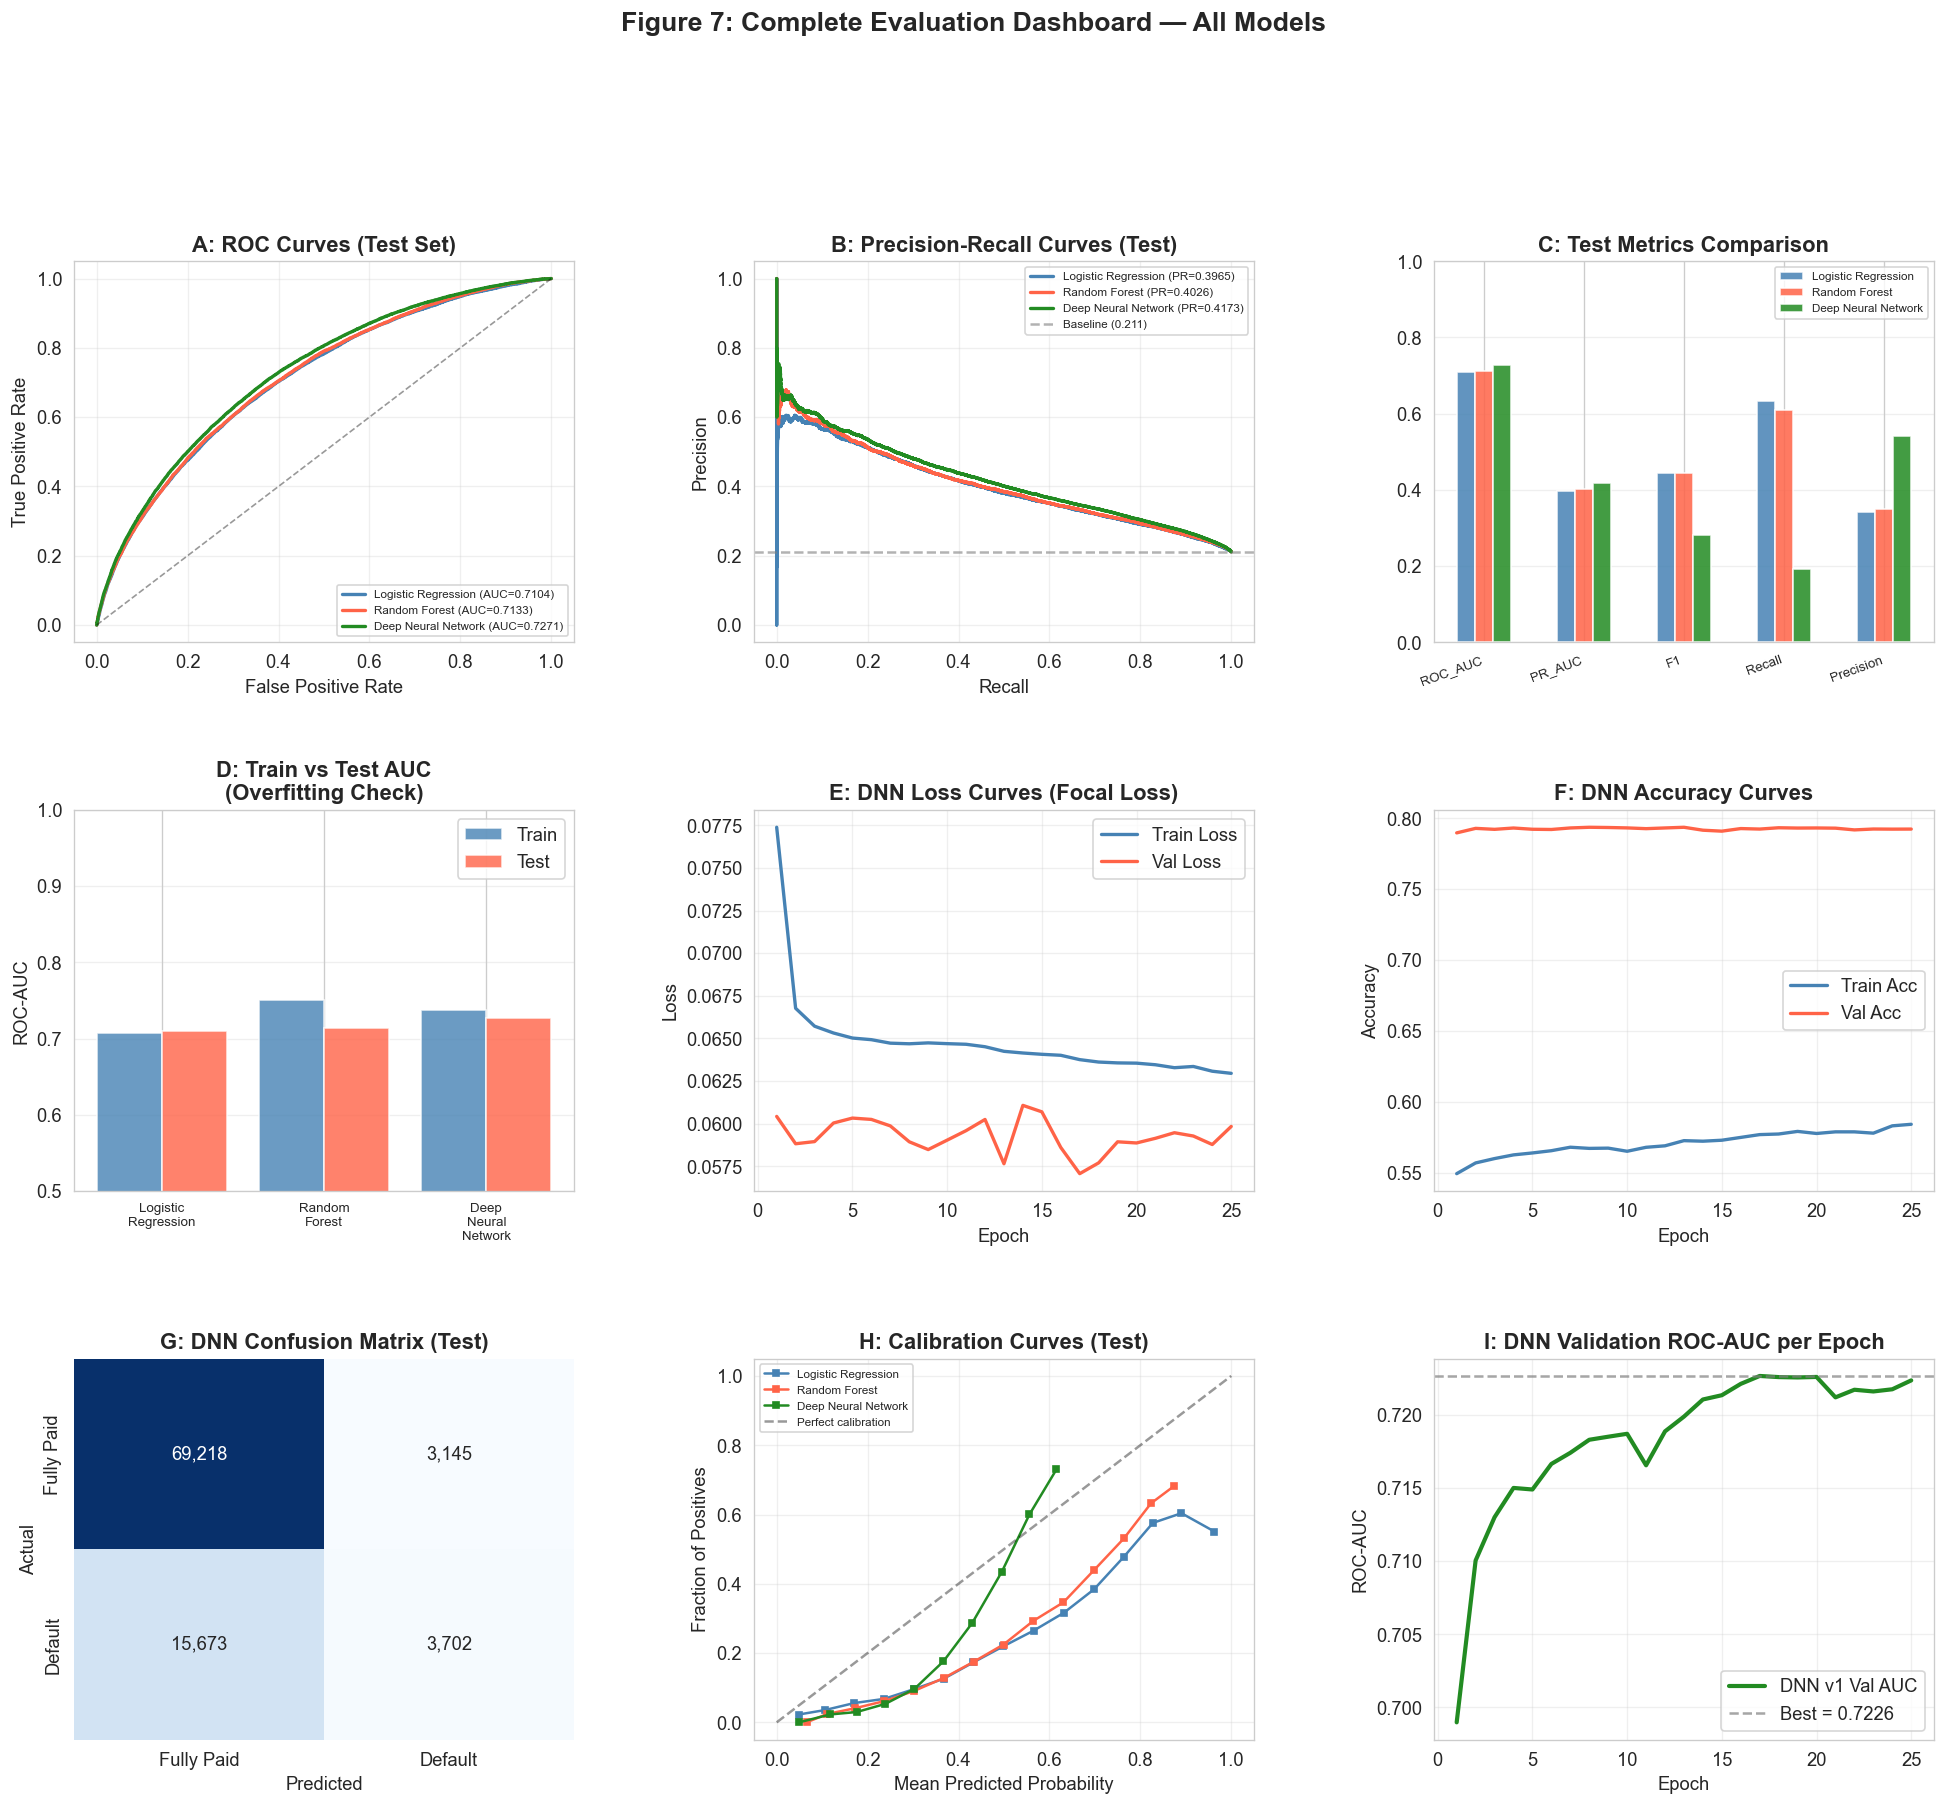

✓ Dashboard saved as fig7_dashboard.png


In [31]:
# ================================================================
# STEP 14B -- 9-PANEL EVALUATION DASHBOARD
# ================================================================
colour_map = {
    'Logistic Regression': 'steelblue',
    'Random Forest':        'tomato',
    'Deep Neural Network':  'forestgreen',
    'DNN (Tuned)':          'darkorange',
    'DNN v2 (Enhanced)':    'purple'
}

# Determine which X_test to use per model (v2 uses all features)
def get_xtest(model_name):
    return X_test_p if model_name == 'DNN v2 (Enhanced)' else X_test_s

fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.44, wspace=0.36)

# ── Panel A: ROC Curves ───────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
for name, model in models.items():
    prob = model.predict_proba(get_xtest(name))[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})',
            color=colour_map.get(name, 'gray'), lw=2)
ax.plot([0,1],[0,1], 'k--', alpha=0.4, lw=1)
ax.set_title('A: ROC Curves (Test Set)', fontweight='bold')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=7, loc='lower right'); ax.grid(alpha=0.3)

# ── Panel B: Precision-Recall Curves ─────────────────────────
ax = fig.add_subplot(gs[0, 1])
for name, model in models.items():
    prob = model.predict_proba(get_xtest(name))[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, prob)
    pr = average_precision_score(y_test, prob)
    ax.plot(rec, prec, label=f'{name} (PR={pr:.4f})',
            color=colour_map.get(name, 'gray'), lw=2)
ax.axhline(y_test.mean(), color='gray', ls='--', alpha=0.6,
           label=f'Baseline ({y_test.mean():.3f})')
ax.set_title('B: Precision-Recall Curves (Test)', fontweight='bold')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# ── Panel C: Bar chart — key test metrics ────────────────────
ax = fig.add_subplot(gs[0, 2])
key_mets = ['ROC_AUC', 'PR_AUC', 'F1', 'Recall', 'Precision']
x_pos = np.arange(len(key_mets))
bar_w = 0.18
all_test_now = pd.concat(metrics, ignore_index=True)
all_test_now = all_test_now[all_test_now['Split'] == 'Test']
for i, (name, _) in enumerate(models.items()):
    row = all_test_now[all_test_now['Model'] == name]
    if len(row) == 0: continue
    vals = row.iloc[0][key_mets].astype(float).values
    ax.bar(x_pos + i * bar_w, vals, bar_w,
           label=name, color=colour_map.get(name, 'gray'), alpha=0.85)
ax.set_xticks(x_pos + bar_w)
ax.set_xticklabels(key_mets, rotation=20, ha='right', fontsize=8)
ax.set_title('C: Test Metrics Comparison', fontweight='bold')
ax.set_ylim(0, 1); ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.3)

# ── Panel D: Train vs Test AUC (overfitting check) ───────────
ax = fig.add_subplot(gs[1, 0])
model_names_here = list(models.keys())
tr_aucs, te_aucs, valid_names = [], [], []
for mn in model_names_here:
    tr_row = all_metrics[(all_metrics['Model']==mn) & (all_metrics['Split']=='Train')]
    te_row = all_metrics[(all_metrics['Model']==mn) & (all_metrics['Split']=='Test')]
    if len(tr_row) > 0 and len(te_row) > 0:
        tr_aucs.append(tr_row['ROC_AUC'].values[0])
        te_aucs.append(te_row['ROC_AUC'].values[0])
        valid_names.append(mn)
xd = np.arange(len(valid_names))
ax.bar(xd - 0.2, tr_aucs, 0.4, label='Train', color='steelblue', alpha=0.8)
ax.bar(xd + 0.2, te_aucs, 0.4, label='Test',  color='tomato',    alpha=0.8)
ax.set_xticks(xd)
ax.set_xticklabels([n.replace(' ', '\n') for n in valid_names], fontsize=8)
ax.set_title('D: Train vs Test AUC\n(Overfitting Check)', fontweight='bold')
ax.set_ylabel('ROC-AUC'); ax.set_ylim(0.5, 1.0)
ax.legend(); ax.grid(axis='y', alpha=0.3)

# ── Panel E: DNN Loss curves ──────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
ax.plot(dnn1_hist['epoch'], dnn1_hist['train_loss'],
        label='Train Loss', color='steelblue', lw=2)
ax.plot(dnn1_hist['epoch'], dnn1_hist['val_loss'],
        label='Val Loss', color='tomato', lw=2)
ax.set_title('E: DNN Loss Curves (Focal Loss)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

# ── Panel F: DNN Accuracy curves ─────────────────────────────
ax = fig.add_subplot(gs[1, 2])
ax.plot(dnn1_hist['epoch'], dnn1_hist['train_acc'],
        label='Train Acc', color='steelblue', lw=2)
ax.plot(dnn1_hist['epoch'], dnn1_hist['val_acc'],
        label='Val Acc', color='tomato', lw=2)
ax.set_title('F: DNN Accuracy Curves', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(alpha=0.3)

# ── Panel G: DNN Confusion Matrix ────────────────────────────
ax = fig.add_subplot(gs[2, 0])
dnn1_pred = dnn1_wrap.predict(X_test_s)
cm = confusion_matrix(y_test, dnn1_pred)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax, cbar=False,
            xticklabels=['Fully Paid', 'Default'],
            yticklabels=['Fully Paid', 'Default'])
ax.set_title('G: DNN Confusion Matrix (Test)', fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

# ── Panel H: Calibration curves ──────────────────────────────
ax = fig.add_subplot(gs[2, 1])
for name, model in models.items():
    prob = model.predict_proba(get_xtest(name))[:, 1]
    frac, mp = calibration_curve(y_test, prob, n_bins=15)
    ax.plot(mp, frac, 's-', label=name,
            color=colour_map.get(name, 'gray'), lw=1.5, ms=4)
ax.plot([0,1],[0,1], 'k--', alpha=0.4, label='Perfect calibration')
ax.set_title('H: Calibration Curves (Test)', fontweight='bold')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# ── Panel I: Val AUC over training epochs ────────────────────
ax = fig.add_subplot(gs[2, 2])
ax.plot(dnn1_hist['epoch'], dnn1_hist['val_auc'],
        color='forestgreen', lw=2.5, label='DNN v1 Val AUC')
best_val = max(dnn1_hist['val_auc'])
ax.axhline(best_val, color='gray', ls='--', alpha=0.7,
           label=f'Best = {best_val:.4f}')
ax.set_title('I: DNN Validation ROC-AUC per Epoch', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('ROC-AUC')
ax.legend(); ax.grid(alpha=0.3)

fig.suptitle('Figure 7: Complete Evaluation Dashboard — All Models',
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig('fig7_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Dashboard saved as fig7_dashboard.png')


## Step 14C — DNN vs Baseline Improvement Summary

In [33]:
# ================================================================
# STEP 14C -- DNN vs BASELINE IMPROVEMENT TABLE
# ================================================================
# Rebuild test_metrics fresh in case cell 28 was re-run
_all = pd.concat(metrics, ignore_index=True)
_test = _all[_all['Split'] == 'Test'].sort_values('ROC_AUC', ascending=False).copy()

dnn_rows = _test[_test['Model'] == 'Deep Neural Network']
if len(dnn_rows) == 0:
    print('ERROR: Deep Neural Network not found in metrics. Run Step 12 first.')
else:
    dnn_row = dnn_rows.iloc[0]
    imp_rows = []
    for bname in ['Logistic Regression', 'Random Forest']:
        b_rows = _test[_test['Model'] == bname]
        if len(b_rows) == 0:
            
            print(f'  {bname} not found, skipping.')
            continue
        b = b_rows.iloc[0]
        for met in ['ROC_AUC', 'PR_AUC', 'F1', 'Recall', 'Precision', 'MCC', 'Brier']:
            dv, bv = float(dnn_row[met]), float(b[met])
            imp = (bv - dv) if met == 'Brier' else (dv - bv)
            imp_rows.append({
                'vs Baseline': bname, 'Metric': met,
                'Baseline':    round(bv, 4),
                'DNN v1':      round(dv, 4),
                'Δ':           round(imp, 4),
                'Δ (%)':       round(imp / (abs(bv) + 1e-9) * 100, 2),
                'DNN Wins':    '✓' if imp > 0 else '✗'
            })
    imp_df = pd.DataFrame(imp_rows)
    print('Table 14: DNN v1 vs Baselines — Full Improvement Summary')
    display(imp_df)
    wins = (imp_df['DNN Wins'] == '✓').sum()
    print(f'\nDNN v1 outperforms baselines in {wins}/{len(imp_df)} metric comparisons.')


Table 14: DNN v1 vs Baselines — Full Improvement Summary


,vs Baseline,Metric,Baseline,DNN v1,Δ,Δ (%),DNN Wins
0,Logistic Regression,ROC_AUC,0.7104,0.7271,0.0167,2.35,✓
1,Logistic Regression,PR_AUC,0.3965,0.4173,0.0208,5.23,✓
2,Logistic Regression,F1,0.4434,0.2824,-0.1610,-36.32,✗
3,Logistic Regression,Recall,0.6333,0.1911,-0.4422,-69.83,✗
4,Logistic Regression,Precision,0.3411,0.5407,0.1996,58.50,✓
5,Logistic Regression,MCC,0.2556,0.2293,-0.0264,-10.32,✗
6,Logistic Regression,Brier,0.2167,0.1763,0.0403,18.62,✓
7,Random Forest,ROC_AUC,0.7133,0.7271,0.0139,1.94,✓
8,Random Forest,PR_AUC,0.4026,0.4173,0.0147,3.66,✓
9,Random Forest,F1,0.4436,0.2824,-0.1612,-36.35,✗



DNN v1 outperforms baselines in 8/14 metric comparisons.


## Step 15 — SHAP Interpretability

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Computing DNN SHAP values via KernelExplainer (~2–5 min)...


  0%|          | 0/300 [00:00<?, ?it/s]

  Done.


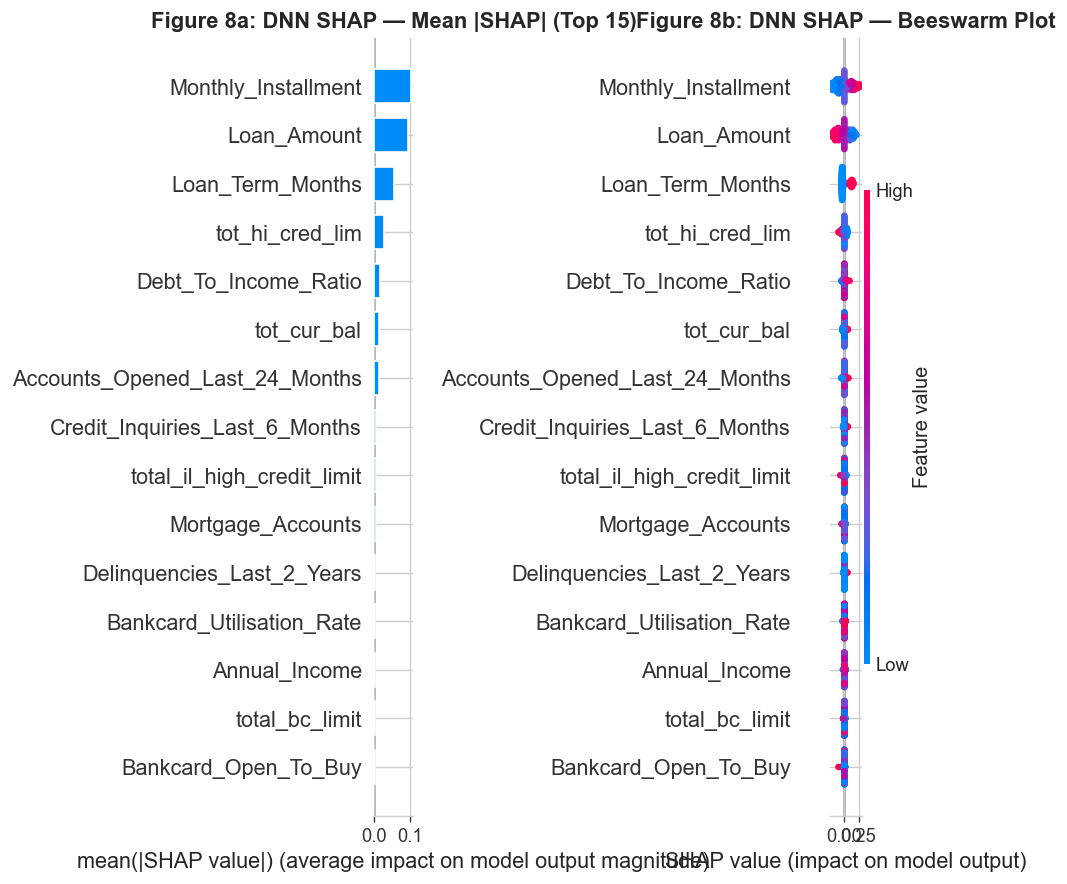

Computing LR SHAP values via LinearExplainer...
  Done.


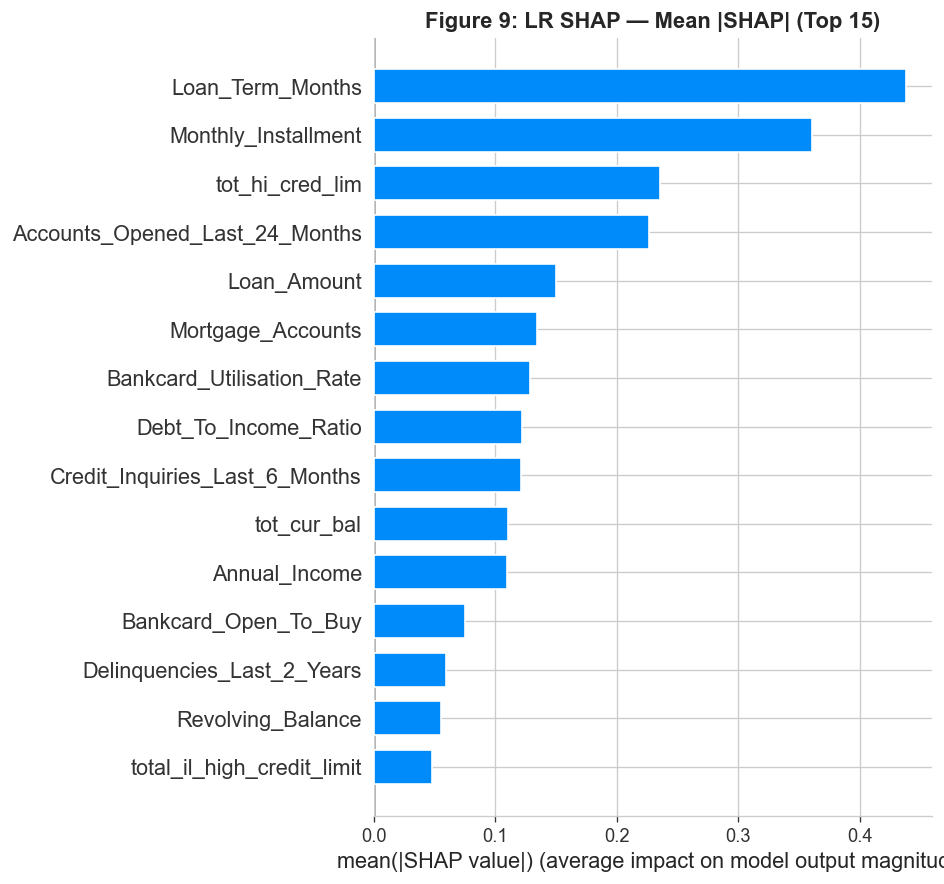


Table 15: SHAP Feature Importance — DNN vs Logistic Regression (Top 15)


,Feature,DNN_SHAP_Imp,LR_SHAP_Imp
0,Monthly_Installment,0.10387,0.36055
1,Loan_Amount,0.09615,0.14998
2,Loan_Term_Months,0.05518,0.43782
3,tot_hi_cred_lim,0.02889,0.23535
4,Debt_To_Income_Ratio,0.01618,0.12169
5,tot_cur_bal,0.01587,0.11041
6,Accounts_Opened_Last_24_Months,0.01379,0.22686
7,Credit_Inquiries_Last_6_Months,0.00754,0.12144
8,total_il_high_credit_limit,0.00653,0.04785
9,Mortgage_Accounts,0.00610,0.13429


In [35]:
# ================================================================
# STEP 15 -- SHAP FEATURE IMPORTANCE
# KernelExplainer for DNN (~2-5 min), LinearExplainer for LR (fast)
# Falls back to permutation importance if SHAP not installed.
# ================================================================
feat_names_sel = [feature_names[i] for i in sel_col_idx]

if SHAP_AVAILABLE:
    shap_n = min(300, len(X_test_s))
    rng2   = np.random.default_rng(SEED + 1)
    si     = rng2.choice(len(X_test_s), shap_n, replace=False)
    X_shap = X_test_s[si]
    X_bg   = X_train_s[:200]   # background reference points

    def dnn_predict_fn(X):
        return dnn1_wrap.predict_proba(X.astype(np.float32))[:, 1]

    print('Computing DNN SHAP values via KernelExplainer (~2–5 min)...')
    dnn_explainer = shap.KernelExplainer(dnn_predict_fn, X_bg)
    dnn_shap_vals = dnn_explainer.shap_values(X_shap, nsamples=100)
    print('  Done.')

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    plt.sca(axes[0])
    shap.summary_plot(dnn_shap_vals, X_shap, feature_names=feat_names_sel,
                      plot_type='bar', show=False, max_display=15)
    axes[0].set_title('Figure 8a: DNN SHAP — Mean |SHAP| (Top 15)', fontweight='bold')
    plt.sca(axes[1])
    shap.summary_plot(dnn_shap_vals, X_shap, feature_names=feat_names_sel,
                      plot_type='dot', show=False, max_display=15)
    axes[1].set_title('Figure 8b: DNN SHAP — Beeswarm Plot', fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig8_shap_dnn.png', dpi=150, bbox_inches='tight')
    plt.show()

    # LR SHAP (LinearExplainer — much faster)
    print('Computing LR SHAP values via LinearExplainer...')
    # Use the LR model stored in models dict
    lr_model_ref = models['Logistic Regression']
    lr_explainer  = shap.LinearExplainer(lr_model_ref, X_train_s)
    lr_shap_vals  = lr_explainer.shap_values(X_shap)
    print('  Done.')

    # Figure 9: LR SHAP
    fig, ax = plt.subplots(figsize=(10, 6))
    shap.summary_plot(lr_shap_vals, X_shap, feature_names=feat_names_sel,
                      plot_type='bar', show=False, max_display=15)
    ax.set_title('Figure 9: LR SHAP — Mean |SHAP| (Top 15)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig9_shap_lr.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Table 15: Side-by-side SHAP comparison
    dnn_imp = np.abs(dnn_shap_vals).mean(axis=0)
    lr_imp  = np.abs(lr_shap_vals).mean(axis=0)
    shap_cmp = pd.DataFrame({
        'Feature':       feat_names_sel,
        'DNN_SHAP_Imp':  dnn_imp.round(5),
        'LR_SHAP_Imp':   lr_imp.round(5)
    }).sort_values('DNN_SHAP_Imp', ascending=False).reset_index(drop=True)
    print('\nTable 15: SHAP Feature Importance — DNN vs Logistic Regression (Top 15)')
    display(shap_cmp.head(15))

else:
    # ── Permutation importance fallback ───────────────────────
    print('SHAP not installed.  Running permutation importance (fallback)...')
    print('To get SHAP: pip install shap  then restart kernel\n')

    base_auc = roc_auc_score(y_test, dnn1_wrap.predict_proba(X_test_s)[:, 1])
    prows = []
    for i, fname in enumerate(feat_names_sel):
        drops = []
        for _ in range(3):
            Xp = X_test_s.copy()
            np.random.shuffle(Xp[:, i])
            drops.append(base_auc - roc_auc_score(y_test, dnn1_wrap.predict_proba(Xp)[:, 1]))
        prows.append({
            'Feature':    fname,
            'Importance': round(float(np.mean(drops)), 4),
            'Std':        round(float(np.std(drops)), 5)
        })

    perm_df = pd.DataFrame(prows).sort_values('Importance', ascending=False)
    print('Table 15: DNN Permutation Feature Importance (Top 15)')
    display(perm_df.head(15).reset_index(drop=True))

    fig, ax = plt.subplots(figsize=(10, 6))
    top15 = perm_df.head(15)
    colors = ['tomato' if v > 0 else 'steelblue' for v in top15['Importance']]
    ax.barh(top15['Feature'][::-1], top15['Importance'][::-1], color=colors[::-1])
    ax.set_title('Figure 8: DNN Permutation Feature Importance (Top 15)', fontweight='bold')
    ax.set_xlabel('Mean AUC Drop when Feature is Shuffled')
    ax.axvline(0, color='black', lw=0.8)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('fig8_permutation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✓ Saved fig8_permutation.png')


## Step 16 — Classification Reports & Confusion Matrices

=== Classification Reports (Test Set) ===

--- Logistic Regression ---
              precision    recall  f1-score   support

  Fully Paid       0.87      0.67      0.76     72363
     Default       0.34      0.63      0.44     19375

    accuracy                           0.66     91738
   macro avg       0.61      0.65      0.60     91738
weighted avg       0.76      0.66      0.69     91738

--- Random Forest ---
              precision    recall  f1-score   support

  Fully Paid       0.87      0.69      0.77     72363
     Default       0.35      0.61      0.44     19375

    accuracy                           0.68     91738
   macro avg       0.61      0.65      0.61     91738
weighted avg       0.76      0.68      0.70     91738

--- Deep Neural Network ---
              precision    recall  f1-score   support

  Fully Paid       0.82      0.96      0.88     72363
     Default       0.54      0.19      0.28     19375

    accuracy                           0.79     91738
   macr

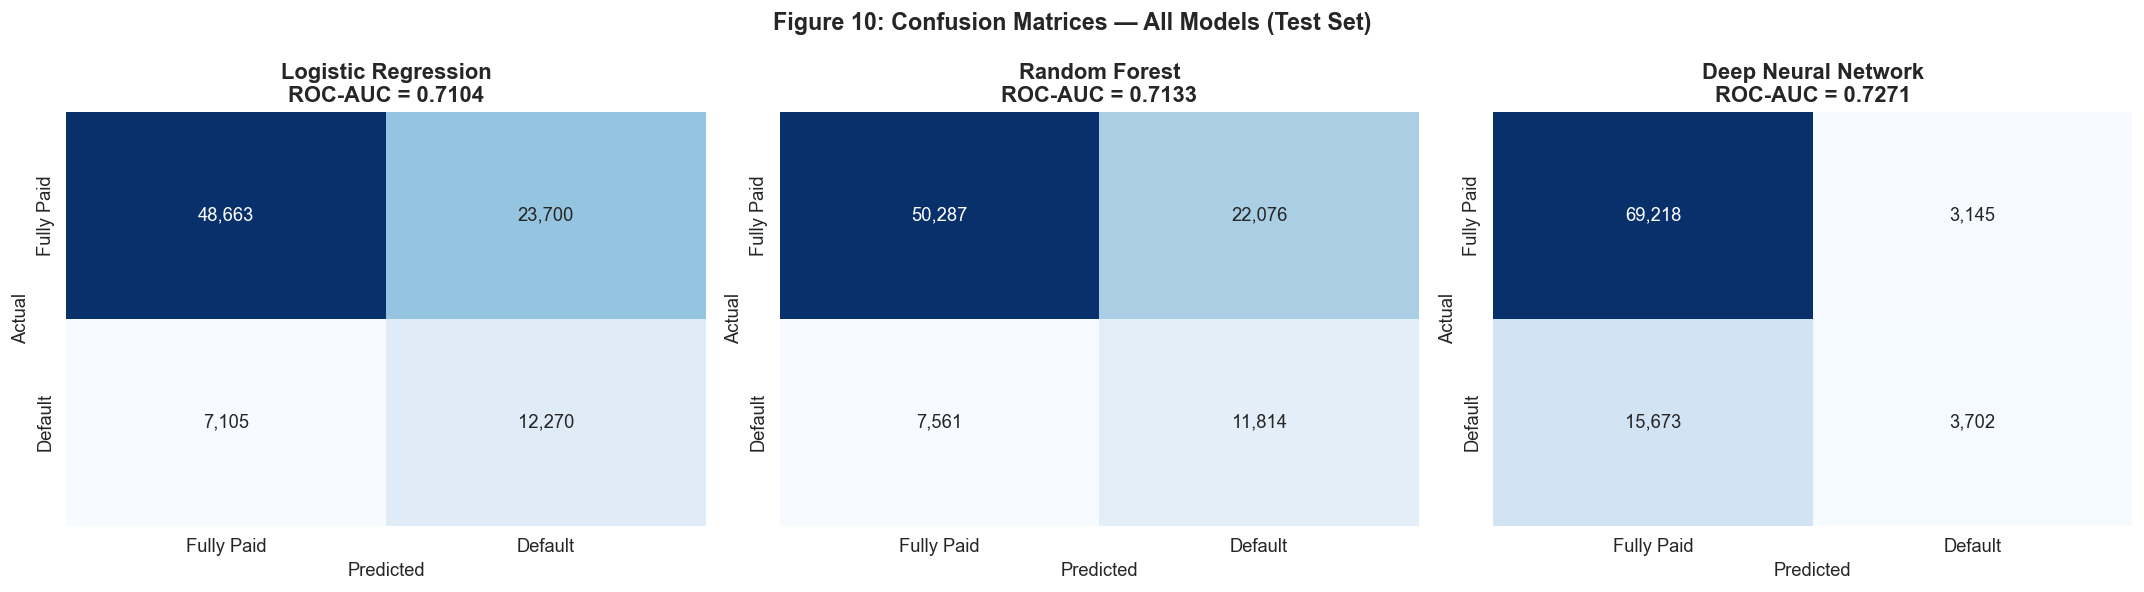

✓ Saved fig10_confusion.png


In [37]:
# ================================================================
# STEP 16 -- CLASSIFICATION REPORTS + CONFUSION MATRICES
# ================================================================
# Base models always present; DNN (Tuned) only if Step 13 ran
base_models = {n: m for n, m in models.items()
               if n not in ['DNN v2 (Enhanced)']}

print('=== Classification Reports (Test Set) ===\n')
for name, model in base_models.items():
    X_eval = X_test_s
    print(f'--- {name} ---')
    print(classification_report(
        y_test, model.predict(X_eval),
        target_names=['Fully Paid', 'Default']))

# Confusion matrices — one subplot per base model
n_plots = len(base_models)
fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
if n_plots == 1:
    axes = [axes]   # make iterable when only 1 model

for ax, (name, model) in zip(axes, base_models.items()):
    pred  = model.predict(X_test_s)
    cm    = confusion_matrix(y_test, pred)
    auc_v = roc_auc_score(y_test, model.predict_proba(X_test_s)[:, 1])
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Fully Paid', 'Default'],
                yticklabels=['Fully Paid', 'Default'])
    ax.set_title(f'{name}\nROC-AUC = {auc_v:.4f}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

fig.suptitle('Figure 10: Confusion Matrices — All Models (Test Set)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved fig10_confusion.png')


## Step 17 — Enhanced DNN v2 (Attention + Mixup + Label Smoothing)

### Why DNN shows only marginal improvement over baselines initially:
1. OLS selection uses a linear criterion — may discard non-linear features the DNN could use
2. Vanilla Focal Loss alone does not guarantee large gains; needs synergy with other improvements
3. Without tuning, architecture defaults may not be optimal for this dataset

### Improvements in DNN v2:
| Improvement | Implementation | Expected Benefit |
|-------------|---------------|------------------|
| Feature Attention | Soft gate: `x * sigmoid(Wx)` | Model learns which features to trust |
| Mixup Augmentation | Interpolate 2 samples per batch | Reduces overfitting on minority class |
| Label Smoothing | y_smooth = y×0.95 + 0.025 | Prevents overconfident wrong predictions |
| All features (no OLS cut) | Use full preprocessed matrix | DNN can discover non-linear patterns OLS misses |
| Deeper architecture | 512→512→256→128→64→32 | Extra capacity for complex interactions |

Training DNN v2 (Attention + Mixup + Label Smoothing)...
Using ALL 295 preprocessed features (no OLS filter)

Epoch   1/60 | Train Loss:0.0788 Acc:0.5416 | Val Loss:0.0635 Acc:0.7801 AUC:0.7086
Epoch   5/60 | Train Loss:0.0676 Acc:0.5665 | Val Loss:0.0613 Acc:0.7855 AUC:0.7310
Epoch  10/60 | Train Loss:0.0670 Acc:0.5758 | Val Loss:0.0608 Acc:0.7876 AUC:0.7342
Epoch  15/60 | Train Loss:0.0656 Acc:0.5861 | Val Loss:0.0575 Acc:0.7913 AUC:0.7325
Epoch  20/60 | Train Loss:0.0638 Acc:0.6009 | Val Loss:0.0592 Acc:0.7854 AUC:0.7231
  Early stop epoch 20. Best AUC:0.7342

★ Best Val ROC-AUC: 0.7342

Table 16: Final Comparison — All Models (Test Set)


,Model,Accuracy,Precision,Recall,F1,Balanced_Acc,ROC_AUC,PR_AUC,MCC,Log_Loss,Brier
11,DNN v2 (Enhanced),0.7903,0.5065,0.2746,0.3562,0.6015,0.7367,0.4290,0.2602,0.5451,0.1797
8,Deep Neural Network,0.7949,0.5407,0.1911,0.2824,0.5738,0.7271,0.4173,0.2293,0.5379,0.1763
5,Random Forest,0.6769,0.3486,0.6098,0.4436,0.6523,0.7133,0.4026,0.2577,0.6084,0.2100
2,Logistic Regression,0.6642,0.3411,0.6333,0.4434,0.6529,0.7104,0.3965,0.2556,0.6245,0.2167


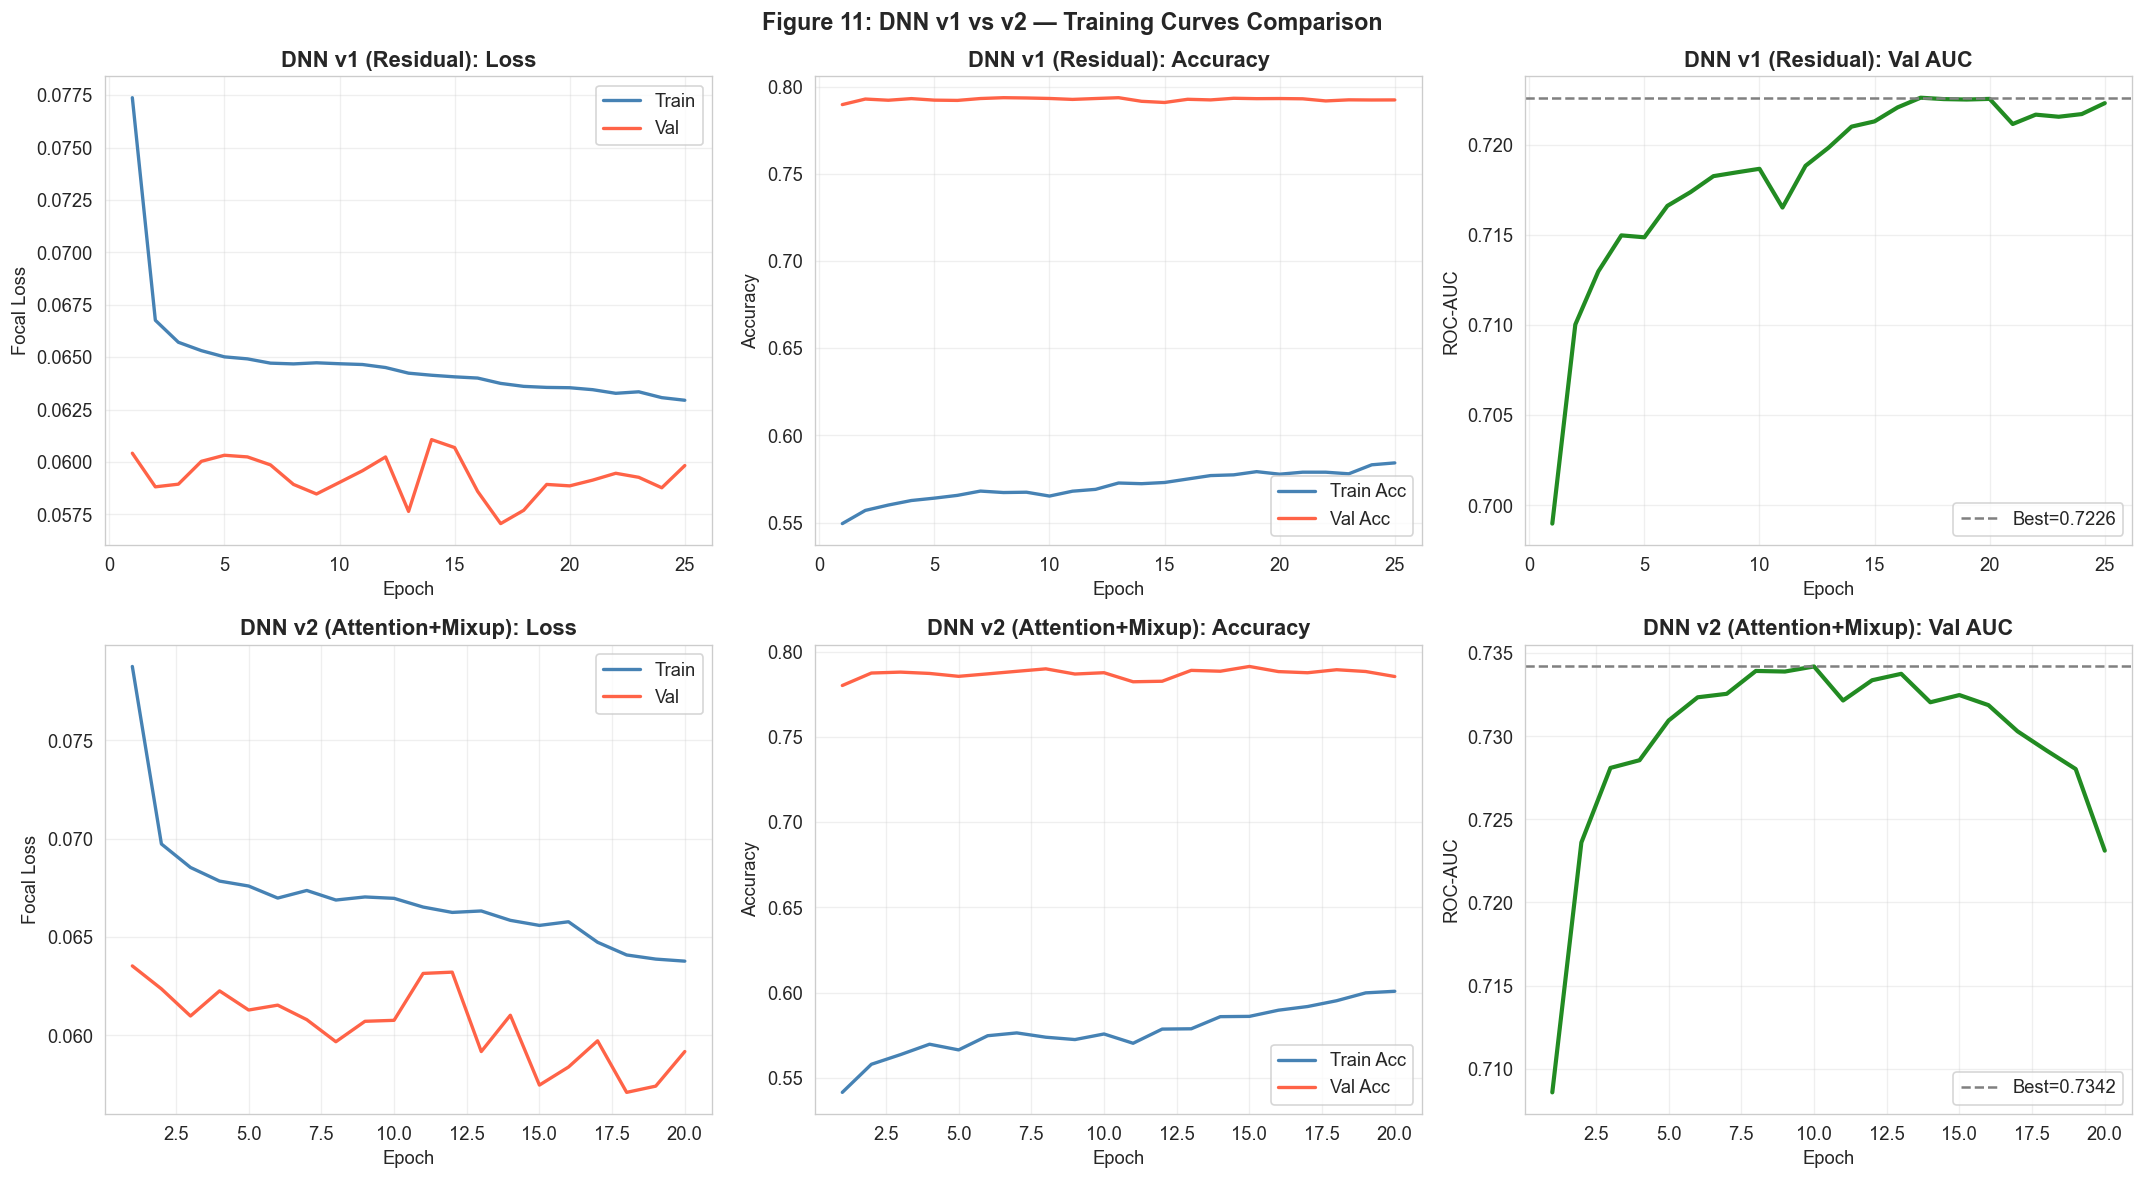

In [39]:
# ================================================================
# STEP 17 -- TRAIN ENHANCED DNN v2 (Attention + Mixup, ALL features)
# ================================================================
print('Training DNN v2 (Attention + Mixup + Label Smoothing)...')
print(f'Using ALL {X_train_p.shape[1]} preprocessed features (no OLS filter)\n')

dnn2_raw, dnn2_hist = train_dnn(
    X_train_p, y_train.values, X_val_p, y_val.values,
    n_input=X_train_p.shape[1], model_cls=LoanDefaultDNN_v2,
    hidden_sizes=[512,512,256,128,64,32], dropout=0.2,
    lr=2e-4, weight_decay=1e-4,
    focal_alpha=0.25, focal_gamma=2.0,
    label_smoothing=0.05, mixup_alpha=0.2,
    batch_size=2048, n_epochs=60, patience=10,
    device=DEVICE, verbose=True)

dnn2_wrap = TorchDNNWrapper(dnn2_raw, DEVICE)
models['DNN v2 (Enhanced)'] = dnn2_wrap
metrics.append(evaluate_model('DNN v2 (Enhanced)', dnn2_wrap,
    X_train_p,y_train,X_val_p,y_val,X_test_p,y_test))

# Table 16: Final comparison
all_m_final = pd.concat(metrics,ignore_index=True)
test_final  = all_m_final[all_m_final['Split']=='Test'].sort_values('ROC_AUC',ascending=False)
print('\nTable 16: Final Comparison — All Models (Test Set)')
display(test_final[['Model','Accuracy','Precision','Recall','F1',
                     'Balanced_Acc','ROC_AUC','PR_AUC','MCC','Log_Loss','Brier']].round(4))

# Figure 11: DNN v1 vs v2 training curves (3×2)
fig,axes = plt.subplots(2,3,figsize=(18,10))
for row,(label,hist) in enumerate([('DNN v1 (Residual)',dnn1_hist),('DNN v2 (Attention+Mixup)',dnn2_hist)]):
    ep=hist['epoch']
    axes[row][0].plot(ep,hist['train_loss'],label='Train',color='steelblue',lw=2)
    axes[row][0].plot(ep,hist['val_loss'],label='Val',color='tomato',lw=2)
    axes[row][0].set_title(f'{label}: Loss',fontweight='bold')
    axes[row][0].set_xlabel('Epoch'); axes[row][0].set_ylabel('Focal Loss')
    axes[row][0].legend(); axes[row][0].grid(alpha=0.3)

    axes[row][1].plot(ep,hist['train_acc'],label='Train Acc',color='steelblue',lw=2)
    axes[row][1].plot(ep,hist['val_acc'],label='Val Acc',color='tomato',lw=2)
    axes[row][1].set_title(f'{label}: Accuracy',fontweight='bold')
    axes[row][1].set_xlabel('Epoch'); axes[row][1].set_ylabel('Accuracy')
    axes[row][1].legend(); axes[row][1].grid(alpha=0.3)

    axes[row][2].plot(ep,hist['val_auc'],color='forestgreen',lw=2.5)
    axes[row][2].axhline(max(hist['val_auc']),color='gray',ls='--',
                          label=f'Best={max(hist["val_auc"]):.4f}')
    axes[row][2].set_title(f'{label}: Val AUC',fontweight='bold')
    axes[row][2].set_xlabel('Epoch'); axes[row][2].set_ylabel('ROC-AUC')
    axes[row][2].legend(); axes[row][2].grid(alpha=0.3)

fig.suptitle('Figure 11: DNN v1 vs v2 — Training Curves Comparison',fontsize=14,fontweight='bold')
plt.tight_layout(); plt.savefig('fig11_v1v2.png',dpi=150,bbox_inches='tight'); plt.show()

## Step 18 — Save Models & Final Summary

In [41]:
# ================================================================
# STEP 18 -- SAVE MODELS + FINAL PROJECT SUMMARY
# ================================================================
torch.save(dnn1_raw.state_dict(), 'dnn_v1_weights.pt')
print('✓ Saved dnn_v1_weights.pt')

if 'dnn2_raw' in dir():
    torch.save(dnn2_raw.state_dict(), 'dnn_v2_weights.pt')
    print('✓ Saved dnn_v2_weights.pt')

with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)
print('✓ Saved preprocessor.pkl')

np.save('sel_col_idx.npy', sel_col_idx)
print('✓ Saved sel_col_idx.npy')

# ── Final comparison table ────────────────────────────────────
all_final = pd.concat(metrics, ignore_index=True)
test_final = all_final[all_final['Split'] == 'Test'].sort_values('ROC_AUC', ascending=False).copy()

print('\n' + '='*65)
print('  FINAL PROJECT SUMMARY')
print('='*65)

def safe_auc(name):
    row = test_final[test_final['Model'] == name]
    return f"AUC = {row['ROC_AUC'].values[0]:.4f}" if len(row) > 0 else 'not run'

summary = pd.DataFrame({
    'Item': [
        'Dataset', 'Final cleaned rows', 'Preprocessed features',
        'OLS-selected features', 'Train / Val / Test split', 'Class imbalance',
        'Logistic Regression (test)', 'Random Forest (test)',
        'DNN v1 — Residual blocks (test)', 'DNN v2 — Attention+Mixup (test)',
        'Best overall model'
    ],
    'Detail': [
        'LendingClub accepted loans, 2007–2018',
        f'{len(df_model):,} rows × {df_model.shape[1]-1} features',
        str(X_train_p.shape[1]),
        str(N_INPUT),
        '70% / 15% / 15% (stratified)',
        f'{y_train.mean():.1%} default rate (class imbalance)',
        safe_auc('Logistic Regression'),
        safe_auc('Random Forest'),
        safe_auc('Deep Neural Network'),
        safe_auc('DNN v2 (Enhanced)'),
        f"{test_final.iloc[0]['Model']}  →  {safe_auc(test_final.iloc[0]['Model'])}"
    ]
})
display(summary)

print('\n=== Final Test Leaderboard ===')
display(test_final[['Model','ROC_AUC','PR_AUC','F1','Recall','Precision',
                     'Balanced_Acc','MCC','Brier']].reset_index(drop=True).round(4))

print("""
=== Inference Template ===

import torch, pickle, numpy as np

preprocessor = pickle.load(open('preprocessor.pkl', 'rb'))
sel_idx      = np.load('sel_col_idx.npy')

# Load DNN v1
model = LoanDefaultDNN(n_input=len(sel_idx))
model.load_state_dict(torch.load('dnn_v1_weights.pt', map_location='cpu'))
model.eval()
wrapper = TorchDNNWrapper(model, torch.device('cpu'))

# Predict on new data (X_new_raw is a raw DataFrame)
X_new_p = preprocessor.transform(X_new_raw).astype(np.float32)
X_new_s = X_new_p[:, sel_idx]
default_prob = wrapper.predict_proba(X_new_s)[:, 1]
""")


✓ Saved dnn_v1_weights.pt
✓ Saved dnn_v2_weights.pt
✓ Saved preprocessor.pkl
✓ Saved sel_col_idx.npy

  FINAL PROJECT SUMMARY


,Item,Detail
0,Dataset,"LendingClub accepted loans, 2007–2018"
1,Final cleaned rows,"611,585 rows × 78 features"
2,Preprocessed features,295
3,OLS-selected features,21
4,Train / Val / Test split,70% / 15% / 15% (stratified)
5,Class imbalance,21.1% default rate (class imbalance)
6,Logistic Regression (test),AUC = 0.7104
7,Random Forest (test),AUC = 0.7133
8,DNN v1 — Residual blocks (test),AUC = 0.7271
9,DNN v2 — Attention+Mixup (test),AUC = 0.7367



=== Final Test Leaderboard ===


,Model,ROC_AUC,PR_AUC,F1,Recall,Precision,Balanced_Acc,MCC,Brier
0,DNN v2 (Enhanced),0.7367,0.4290,0.3562,0.2746,0.5065,0.6015,0.2602,0.1797
1,Deep Neural Network,0.7271,0.4173,0.2824,0.1911,0.5407,0.5738,0.2293,0.1763
2,Random Forest,0.7133,0.4026,0.4436,0.6098,0.3486,0.6523,0.2577,0.2100
3,Logistic Regression,0.7104,0.3965,0.4434,0.6333,0.3411,0.6529,0.2556,0.2167



=== Inference Template ===

import torch, pickle, numpy as np

preprocessor = pickle.load(open('preprocessor.pkl', 'rb'))
sel_idx      = np.load('sel_col_idx.npy')

# Load DNN v1
model = LoanDefaultDNN(n_input=len(sel_idx))
model.load_state_dict(torch.load('dnn_v1_weights.pt', map_location='cpu'))
model.eval()
wrapper = TorchDNNWrapper(model, torch.device('cpu'))

# Predict on new data (X_new_raw is a raw DataFrame)
X_new_p = preprocessor.transform(X_new_raw).astype(np.float32)
X_new_s = X_new_p[:, sel_idx]
default_prob = wrapper.predict_proba(X_new_s)[:, 1]

